# Comparación de métodos de verificación de FCMs

Este notebook ejecuta un experimento modular que compara tres métodos de verificación de espacios de estados para Mapas Cognitivos Difusos (FCM): **aritmético**, **simbólico** y **lookahead**.

Incluye:
- Grid de mapas generados aleatoriamente con caché en `maps.json`
- Bucle de comparación con caché en `resultados.csv` y guardado de las series por configuración en `estados/*.npz`
- Métricas por método: covering, gap promedio, convergencia y validez
- Análisis de contención del intervalo final de lookahead frente a los demás métodos
- Análisis de encogimiento de las series (anidadas y estrictamente contrayentes)
- Soporte CPU/CUDA (`get_default_device`) y precisión configurable (`DTYPE`: `float64` o `float32`)

Ejecutar las celdas en orden, de arriba hacia abajo.

> Nota: para regenerar los resultados tras cambiar `DTYPE`, borra `resultados.csv` y `estados/`.

# TODO:
- Deben filtrarse las gráficas, no los datos en las graficas. Lo que no quiero es que sena tantas gráficas en la imagen.

## Configuración

Parámetros del experimento y del grid de mapas. Ajustables libremente antes de ejecutar.

### Precisión numérica
- `DTYPE`: tipo de dato de todos los tensores. Cambiar `torch.float64` → `torch.float32` para más velocidad (especialmente en CUDA)

### Grid de generación de mapas
- `N_CONCEPTS_OPTIONS`: número de conceptos a probar
- `DENSITY_OPTIONS`: densidades de la matriz de influencia `W`
- `SEEDS`: seeds para reproducibilidad

### Parámetros del experimento
- `RESUME_TESTING`: si el CSV existe, reutilizarlo como caché
- `SAVE_EVERY_ITERS`: cada cuántas iteraciones se guarda
- `EPSILON`: tolerancia numérica
- `INPUT_LOWER_BOUND` / `INPUT_UPPER_BOUND`: cotas de los intervalos iniciales
- `ACTIVATION_FUNCTION`: función de activación (`sigmoid` o `tanh`)
- `NUM_SAMPLES`: muestras para la simulación (ground truth)
- `NUM_ITERS`: iteraciones de la serie
- `PHI_OPTIONS`: valores de `phi` a probar
- `LOOKAHEAD_K`: ventana de lookahead (`None` = cadena hasta el final, equivale a `k = NUM_ITERS`)
- `STATES_DIR`: directorio con un `.npz` por `(uuid, phi)` con las series de intervalos de cada iteración (un archivo por configuración)


In [35]:
import torch

# <<< PRECISIÓN >>>
# torch.float64: precisión doble (máxima exactitud, lento en GPU de consumo)
# torch.float32: precisión simple (mucho más rápido en CUDA)
# Cambiar aquí afecta a todo el experimento (mapas, métodos y análisis).
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

MAPS_JSON = "maps.json"
CSV_FILE = "resultados.csv"
STATES_DIR = (
    "estados"  # intervalos por iteración y configuración (un .npz por (uuid, phi))
)

N_CONCEPTS_OPTIONS = [6, 12, 20]

# N_CONCEPTS_OPTIONS = [
#     2,
#     3,
#     4,
#     5,
#     6,
#     7,
#     8,
#     9,
#     10,
#     11,
#     12,
#     13,
#     14,
#     15,
#     16,
#     17,
#     18,
#     19,
#     20,
# ]
# DENSITY_OPTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
DENSITY_OPTIONS = [0.3, 0.6, 0.9]
SEEDS = [42]
# SEEDS = [42, 123, 7]

RESUME_TESTING = True
SAVE_EVERY_ITERS = 20
EPSILON = 1e-6
INPUT_LOWER_BOUND = 0.0
INPUT_UPPER_BOUND = 1.0
ACTIVATION_FUNCTION = "sigmoid"
NUM_SAMPLES = 100
NUM_ITERS = 50
# PHI_OPTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
PHI_OPTIONS = [0.3, 0.6, 1.0]
LOOKAHEAD_K = None  # None = cadena de lookahead hasta el final (k = NUM_ITERS)
SHOW_SAMPLED_3D = False  # False oculta Real Activations en la malla 3D de covering

## Mapas (caché)

Genera o carga `maps.json` siguiendo la filosofía de caché:
- Si `MAPS_JSON` ya existe, se reutiliza.
- Si no, se generan los mapas (un mapa por `(n_concepts, density, seed)`, con seed fija por mapa) y se guardan.

In [36]:
import json
import os

import torch

from core.utils import generate_random_matrix


def generate_maps(
    n_concepts_options: list[int],
    density_options: list[float],
    seeds: list[int],
) -> list[dict]:
    """Genera un mapa por (n_concepts, density, seed) con seed fija por mapa."""
    samples = []
    for n_concepts in n_concepts_options:
        for density in density_options:
            for seed in seeds:
                torch.manual_seed(seed)
                samples.append(
                    {
                        "uuid": f"n{n_concepts}_d{density:g}_s{seed}",
                        "n_concepts": n_concepts,
                        "density": density,
                        "weigths": generate_random_matrix(n_concepts, density).tolist(),
                    }
                )
    return samples


if os.path.exists(MAPS_JSON):
    print(f"Caché: {MAPS_JSON} ya existe, se reutiliza")
    with open(MAPS_JSON, "r") as f:
        samples = json.load(f)
else:
    print(f"{MAPS_JSON} no existe: generando mapas...")
    samples = generate_maps(N_CONCEPTS_OPTIONS, DENSITY_OPTIONS, SEEDS)
    with open(MAPS_JSON, "w") as f:
        json.dump(samples, f, indent=2)
    print(f"Guardados {len(samples)} mapas en {MAPS_JSON}")

print(f"Total de mapas cargados: {len(samples)}")

Caché: maps.json ya existe, se reutiliza
Total de mapas cargados: 570


## Configuración de PyTorch

Selección de dispositivo, tipo de dato y modo de gradientes:
- `device`: `cuda` si está disponible, si no `cpu`
- `DTYPE`: definido en la celda de Configuración (`float64` por defecto; cambiar a `torch.float32` para GPU)
- Gradientes desactivados (`set_grad_enabled(False)`)
- Impresión de tensores con precisión extendida (`set_printoptions`)

In [37]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
torch.set_printoptions(precision=30, sci_mode=False)

print(f"Device: {device}, dtype: {DTYPE}")

Device: cpu, dtype: torch.float64


## Imports — intervalo y métricas

Funciones básicas del núcleo: generación de entradas y muestras, redondeo hacia fuera, comprobaciones de contención, cubrimiento, gap promedio y convergencia.

In [38]:
import core
from core import (
    generate_inputs,
    generate_input_samples,
    upwards_rounding,
    downwards_rounding,
    outwards_rounding,
    is_inside_state,
    state_series_from_samples,
    is_inside_state_series,
    margin,
    states_intersection,
    covering,
    average_gap,
    convergence_iteration,
    series_is_nested,
    series_is_strictly_contracting,
)

## Imports — state-space simbólico

Funciones de relajación simbólica y construcción de series de estado: espacio de estados inducido, concretización, propagación, iteración simbólica/aritmética y `rescaled_reasoning` (referencia muestral).

In [39]:
from core import (
    get_function_data,
    lower_relaxation,
    upper_relaxation,
    induced_state_space,
    concretize_state_space,
    propagate_state_space,
    apply_relaxed_activation,
    symbolic_iteration,
    arithmetic_iteration,
    containment_guided_state_space,
    interval_state_space,
    rescaled_reasoning,
    overapproximation_from_relaxations,
    symbolic_state_space,
    warm_start_symbolic_state_space,
)

## Registry de métodos

Para cambiar la comparación, edita `METHODS` (quitar/añadir métodos y activar o desactivar la comprobación de validez, clave `sound`) y `METHOD_ORDER`.

Cada método recibe `(ctx, states)` y devuelve la serie de estados `(max_iters + 1, 2, n_concepts)`:
- `ctx`: dict con `Wt`, `inputs`, `activation`, `phi`, `iters`, `device`, `eps`, `lookahead_k`, ...
- `states`: dict con las series ya calculadas de los métodos anteriores en `METHOD_ORDER` (para resolver dependencias).

In [40]:
from experimental.methods import lookahead_state_space


def run_arithmetic(ctx: dict, states: dict) -> torch.Tensor:
    return interval_state_space(
        ctx["Wt"],
        ctx["inputs"],
        ctx["activation"],
        ctx["phi"],
        ctx["iters"],
        device=ctx["device"],
    )


def run_symbolic(ctx: dict, states: dict) -> torch.Tensor:
    symbolic = symbolic_state_space(
        ctx["Wt"],
        ctx["inputs"],
        ctx["activation"],
        ctx["phi"],
        ctx["iters"],
        overapprox_threshold=None,
        device=ctx["device"],
    )
    return concretize_state_space(symbolic, ctx["inputs"], device=ctx["device"])


def run_lookahead(ctx: dict, states: dict) -> torch.Tensor:
    return lookahead_state_space(
        ctx["Wt"],
        ctx["inputs"],
        ctx["activation"],
        ctx["phi"],
        k=ctx["lookahead_k"],
        max_iters=ctx["iters"],
        baseline_interval_series=states["arithmetic"],
        device=ctx["device"],
    )


METHODS = {
    "arithmetic": {"run": run_arithmetic, "sound": True},
    "symbolic": {"run": run_symbolic, "sound": True},
    "lookahead": {"run": run_lookahead, "sound": True},
}

METHOD_ORDER = ["arithmetic", "symbolic", "lookahead"]

CONTAINMENT_MATRIX = False


def compute_methods(ctx: dict) -> dict:
    """Ejecuta todos los métodos en METHOD_ORDER resolviendo dependencias."""
    states: dict = {}
    for name in METHOD_ORDER:
        states[name] = METHODS[name]["run"](ctx, states)
    return states


def compute_stats(
    ctx: dict,
    states: dict,
    simulated_states: torch.Tensor,
    sampled_states: torch.Tensor,
) -> dict:
    """Calcula las métricas por método (covering, gap, convergencia, validez)."""
    stats = {
        "uuid": ctx["uuid"],
        "n_concepts": ctx["n_concepts"],
        "density": ctx["density"],
        "phi": ctx["phi"],
    }
    eps = ctx["eps"]

    for name in METHOD_ORDER:
        series = states[name]
        stats[f"{name}_covering"] = covering(series)
        stats[f"{name}_converged_at"] = convergence_iteration(series, eps)
        stats[f"{name}_average_gap"] = average_gap(series, simulated_states)
        if METHODS[name]["sound"]:
            stats[f"{name}_is_valid"] = is_inside_state_series(
                sampled_states, series, tolerance=eps
            )

    if CONTAINMENT_MATRIX:
        for a in METHOD_ORDER:
            for b in METHOD_ORDER:
                if a == b:
                    continue
                stats[f"{a}_inside_{b}"] = is_inside_state_series(
                    states[a], states[b], tolerance=eps
                )

    return stats

## Bucle de comparación

Recorre cada mapa y cada `phi`, ejecuta los métodos del registry y calcula las métricas.

1. Para cada `(uuid, phi)` se construye el `ctx` con los parámetros de configuración.
2. Se simula el ground truth muestral (`rescaled_reasoning`) y se calcula `sampled_covering`.
3. Se ejecutan `compute_methods(ctx)` y `compute_stats(...)`, acumulando los resultados.
4. El CSV se guarda cada `SAVE_EVERY_ITERS` muestras; Ctrl+C (`SIGINT`) detiene el bucle guardando lo procesado y `RESUME_TESTING` permite reanudar.

In [41]:
from math import isnan
import os
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import signal

interrupted = False


def handler(signum, frame):
    global interrupted
    interrupted = True


signal.signal(signal.SIGINT, handler)


def _csv_row_is_complete(row: pd.Series) -> bool:
    """Fila de CSV válida: presentes y sin NaN las métricas esenciales."""
    essentials = (
        [f"{m}_covering" for m in METHOD_ORDER]
        + [f"{m}_average_gap" for m in METHOD_ORDER]
        + [f"{m}_is_valid" for m in METHOD_ORDER if METHODS[m]["sound"]]
        + ["sampled_covering"]
    )
    if not all(c in row.index for c in essentials):
        return False
    return bool(row[essentials].notna().all())


def _npz_is_valid(uuid: str, phi: float) -> bool:
    """El .npz de la configuración existe y contiene todos los métodos."""
    path = os.path.join(STATES_DIR, f"{uuid}_phi{phi:g}.npz")
    if not os.path.exists(path):
        return False
    try:
        with np.load(path) as data:
            return all(m in data for m in METHOD_ORDER)
    except Exception:
        return False


data = []
dataframe = pd.DataFrame()
processed_sample_indexes = set()
csv_found = False

if RESUME_TESTING:
    try:
        dataframe = pd.read_csv(CSV_FILE, index_col=0)

        valid_rows = dataframe.apply(_csv_row_is_complete, axis=1)
        n_invalid = int((~valid_rows).sum())
        if n_invalid:
            print(
                f"CSV con {n_invalid} filas incompletas o inválidas (se recalcularán)"
            )

        # Solo se reutilizan configuraciones cuya fila CSV es válida Y cuyo .npz
        # de intervalos existe y contiene todos los métodos.
        processed_sample_indexes = {
            (uuid, phi)
            for uuid, phi in zip(
                dataframe.loc[valid_rows, "uuid"], dataframe.loc[valid_rows, "phi"]
            )
            if _npz_is_valid(uuid, phi)
        }
        csv_found = True
    except FileNotFoundError:
        print("No se encontró el archivo .csv")

# Corrida desde cero: limpiar estados guardados de corridas anteriores.
if not csv_found and os.path.isdir(STATES_DIR):
    shutil.rmtree(STATES_DIR)

os.makedirs(STATES_DIR, exist_ok=True)

try:
    for sample_index, sample in enumerate(tqdm(samples)):
        if interrupted:
            print("Detenido por el usuario.")
            break

        n_concepts = sample["n_concepts"]

        inputs = generate_inputs(
            n_concepts=n_concepts,
            l=INPUT_LOWER_BOUND,
            u=INPUT_UPPER_BOUND,
            device=device,
        )
        W = torch.tensor(sample["weigths"], device=device)
        Wt = W.T

        for phi in PHI_OPTIONS:
            if interrupted:
                break

            if (sample["uuid"], phi) in processed_sample_indexes:
                continue

            ctx = {
                "uuid": sample["uuid"],
                "n_concepts": n_concepts,
                "density": sample["density"],
                "phi": phi,
                "Wt": Wt,
                "inputs": inputs,
                "activation": ACTIVATION_FUNCTION,
                "iters": NUM_ITERS,
                "device": device,
                "eps": EPSILON,
                "lookahead_k": LOOKAHEAD_K,
            }

            # Aproximación muestral (ground truth)
            A = generate_input_samples(
                NUM_SAMPLES, n_concepts, INPUT_LOWER_BOUND, INPUT_UPPER_BOUND
            )
            simulated_states = rescaled_reasoning(
                A,
                W,
                T=NUM_ITERS,
                phi=phi,
                transfer_function=(
                    torch.sigmoid if ACTIVATION_FUNCTION == "sigmoid" else torch.tanh
                ),
                device=device,
            )
            sampled_states = state_series_from_samples(simulated_states)

            # Ejecutar métodos del registry y calcular métricas
            states = compute_methods(ctx)
            stats = compute_stats(ctx, states, simulated_states, sampled_states)
            stats["sampled_covering"] = covering(sampled_states)

            # Guardar series de intervalos por iteración (un .npz por configuración)
            path = os.path.join(STATES_DIR, f"{sample['uuid']}_phi{phi:g}.npz")
            np.savez_compressed(
                path,
                **{name: states[name].cpu().numpy() for name in METHOD_ORDER},
            )

            if any([isnan(x) for x in stats.values() if isinstance(x, float)]):
                print("NaN values found!!!")

            if any(
                not stats[f"{name}_is_valid"]
                for name in METHOD_ORDER
                if METHODS[name]["sound"]
            ):
                print("Validez: muestras fuera del intervalo de algún método!!!")

            data.append(stats)

        if (sample_index + 1) % SAVE_EVERY_ITERS == 0:
            dataframe = pd.concat([dataframe, pd.DataFrame(data)], ignore_index=True)
            dataframe.to_csv(CSV_FILE)
            data = []
finally:
    dataframe = pd.concat([dataframe, pd.DataFrame(data)], ignore_index=True)
    dataframe.to_csv(CSV_FILE)

100%|██████████| 570/570 [00:27<00:00, 20.87it/s]


## Análisis / diagnóstico de resultados

Reportes de diagnóstico sobre `dataframe` (resultados del bucle):

- **NaN**: filas con valores nulos en las métricas (`_covering` / `_average_gap`).
- **Validez**: métodos cuyas muestras simuladas (ground truth) quedan fuera del intervalo. `NaN` cuenta como fallo; se usa `== False` en vez de `~` porque las columnas pueden ser `object` (bool + NaN).
- **Contención**: pares `a` no contenido en `b` (solo si `CONTAINMENT_MATRIX` está activado).

Cada reporte se muestra únicamente si hay filas (`show_if_not_empty`).

In [42]:
from IPython.display import display


def show_if_not_empty(dframe: pd.DataFrame) -> None:
    """Muestra el dataframe solo si tiene filas."""
    if not dframe.empty:
        display(dframe)


print("NaN Values Report Per Column:")
print(dataframe.isnull().sum())
print()

# Filas con NaN en métricas clave
metric_cols = [
    c
    for c in dataframe.columns
    if c.endswith("_covering") or c.endswith("_average_gap")
]
df_nans = dataframe[dataframe[metric_cols].isnull().any(axis=1)]
print(f"Filas con NaN en métricas: {len(df_nans)}")
show_if_not_empty(df_nans)

# Validez: métodos cuyas muestras simuladas (ground truth) quedan fuera.
# NaN cuenta como fallo (el método no produjo un intervalo verificable).
# Se usa == False en vez de ~ porque las columnas pueden ser object
# (bool + NaN) y ~ sobre Python bool/float da resultados erróneos.
valid_cols = [f"{name}_is_valid" for name in METHOD_ORDER if METHODS[name]["sound"]]
if valid_cols:
    not_sound = (dataframe[valid_cols].fillna(False) == False).any(axis=1)
    df_not_sound = dataframe[not_sound]
else:
    df_not_sound = dataframe.iloc[0:0]
print(
    f"Filas con fallos de validez (muestras fuera del intervalo): {len(df_not_sound)}"
)
show_if_not_empty(df_not_sound)

# Contención entre métodos (a no contenido en b). NaN cuenta como contención rota.
inside_cols = [c for c in dataframe.columns if "_inside_" in c]
if inside_cols:
    not_inside = (dataframe[inside_cols].fillna(False) == False).any(axis=1)
    df_not_inside = dataframe[not_inside]
else:
    df_not_inside = dataframe.iloc[0:0]
print(f"Filas con contención rota (a no contenido en b): {len(df_not_inside)}")
show_if_not_empty(df_not_inside)

NaN Values Report Per Column:
uuid                            0
n_concepts                      0
density                         0
phi                             0
arithmetic_covering             0
arithmetic_converged_at      5335
arithmetic_average_gap          0
arithmetic_runtime_s            0
arithmetic_is_valid             0
symbolic_covering               0
symbolic_converged_at        5328
symbolic_average_gap            0
symbolic_runtime_s              0
symbolic_is_valid               0
rectified_covering              0
rectified_converged_at       5183
rectified_average_gap           0
rectified_runtime_s             0
rectified_is_valid              0
lookahead_10_covering           0
lookahead_10_converged_at    5157
lookahead_10_average_gap        0
lookahead_10_runtime_s          0
lookahead_10_is_valid           0
lookahead_covering              0
lookahead_converged_at       5157
lookahead_average_gap           0
lookahead_runtime_s             0
lookahead_is_valid

## Gráficas

Una sola celda con toda la lógica de plotting. Métodos a graficar: los del registry más la envolvente muestral (`sampled`) si el CSV la incluye.

### Textos
- `METHODS_LABELS`: nombres de los métodos en las gráficas.
- `VAR_LABELS`: nombres de los ejes (`phi`, Número de neuronas, Conectividad).
- `METRIC_LABELS`: nombres de las métricas (Cubrimiento, Desviación).

### Configuración
- `GRID_PHI`, `GRID_N_CONCEPTS`, `GRID_DENSITY`: filtros de subplots (`None` = todos).
- `PLOT_COVERING_VS`, `PLOT_GAP_VS`, `PLOT_GAP_STD_PHI`, `PLOT_SURFACES`: qué graficar.
- `PLOT_Y_FROM_ZERO`: eje y (2D) desde 0 hasta `max(1, máximo)`.
- `PLOT_Z_FROM_ZERO`: eje de altura (3D) desde 0 hasta `max(1, máximo)`; colores del mapa normalizados a esa escala (0 → azul, ≥ 1 → rojo).

### Gráficas generadas
- Cubrimiento promedio (con min–max) variando `phi`, `n_concepts` y `density`.
- Desviación (gap) variando `phi`.
- Gap promedio ± desviación estándar por método.
- Superficies 3D por método (`gap` y `covering`).

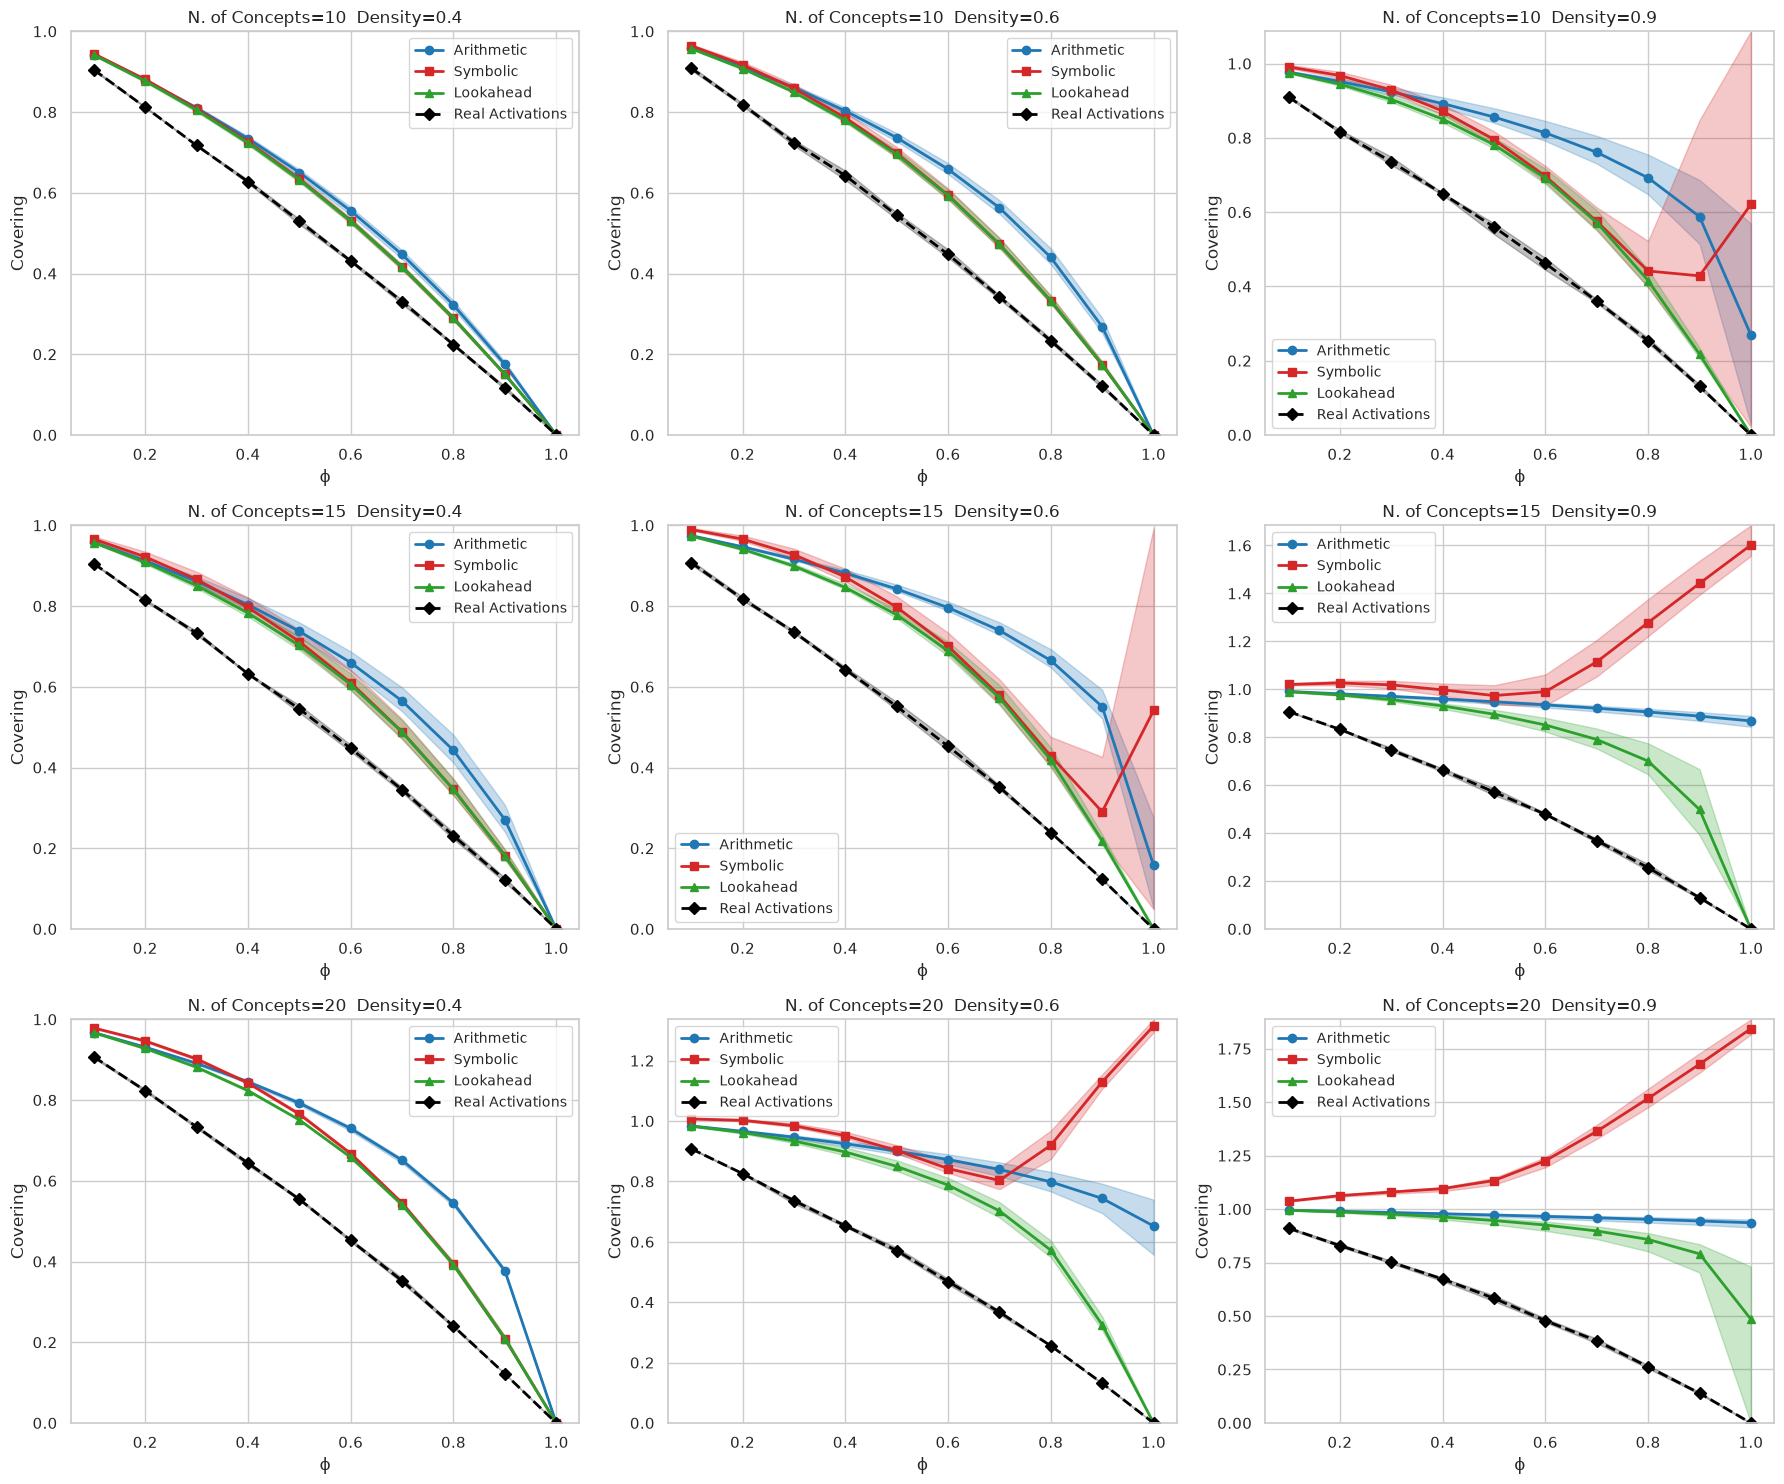

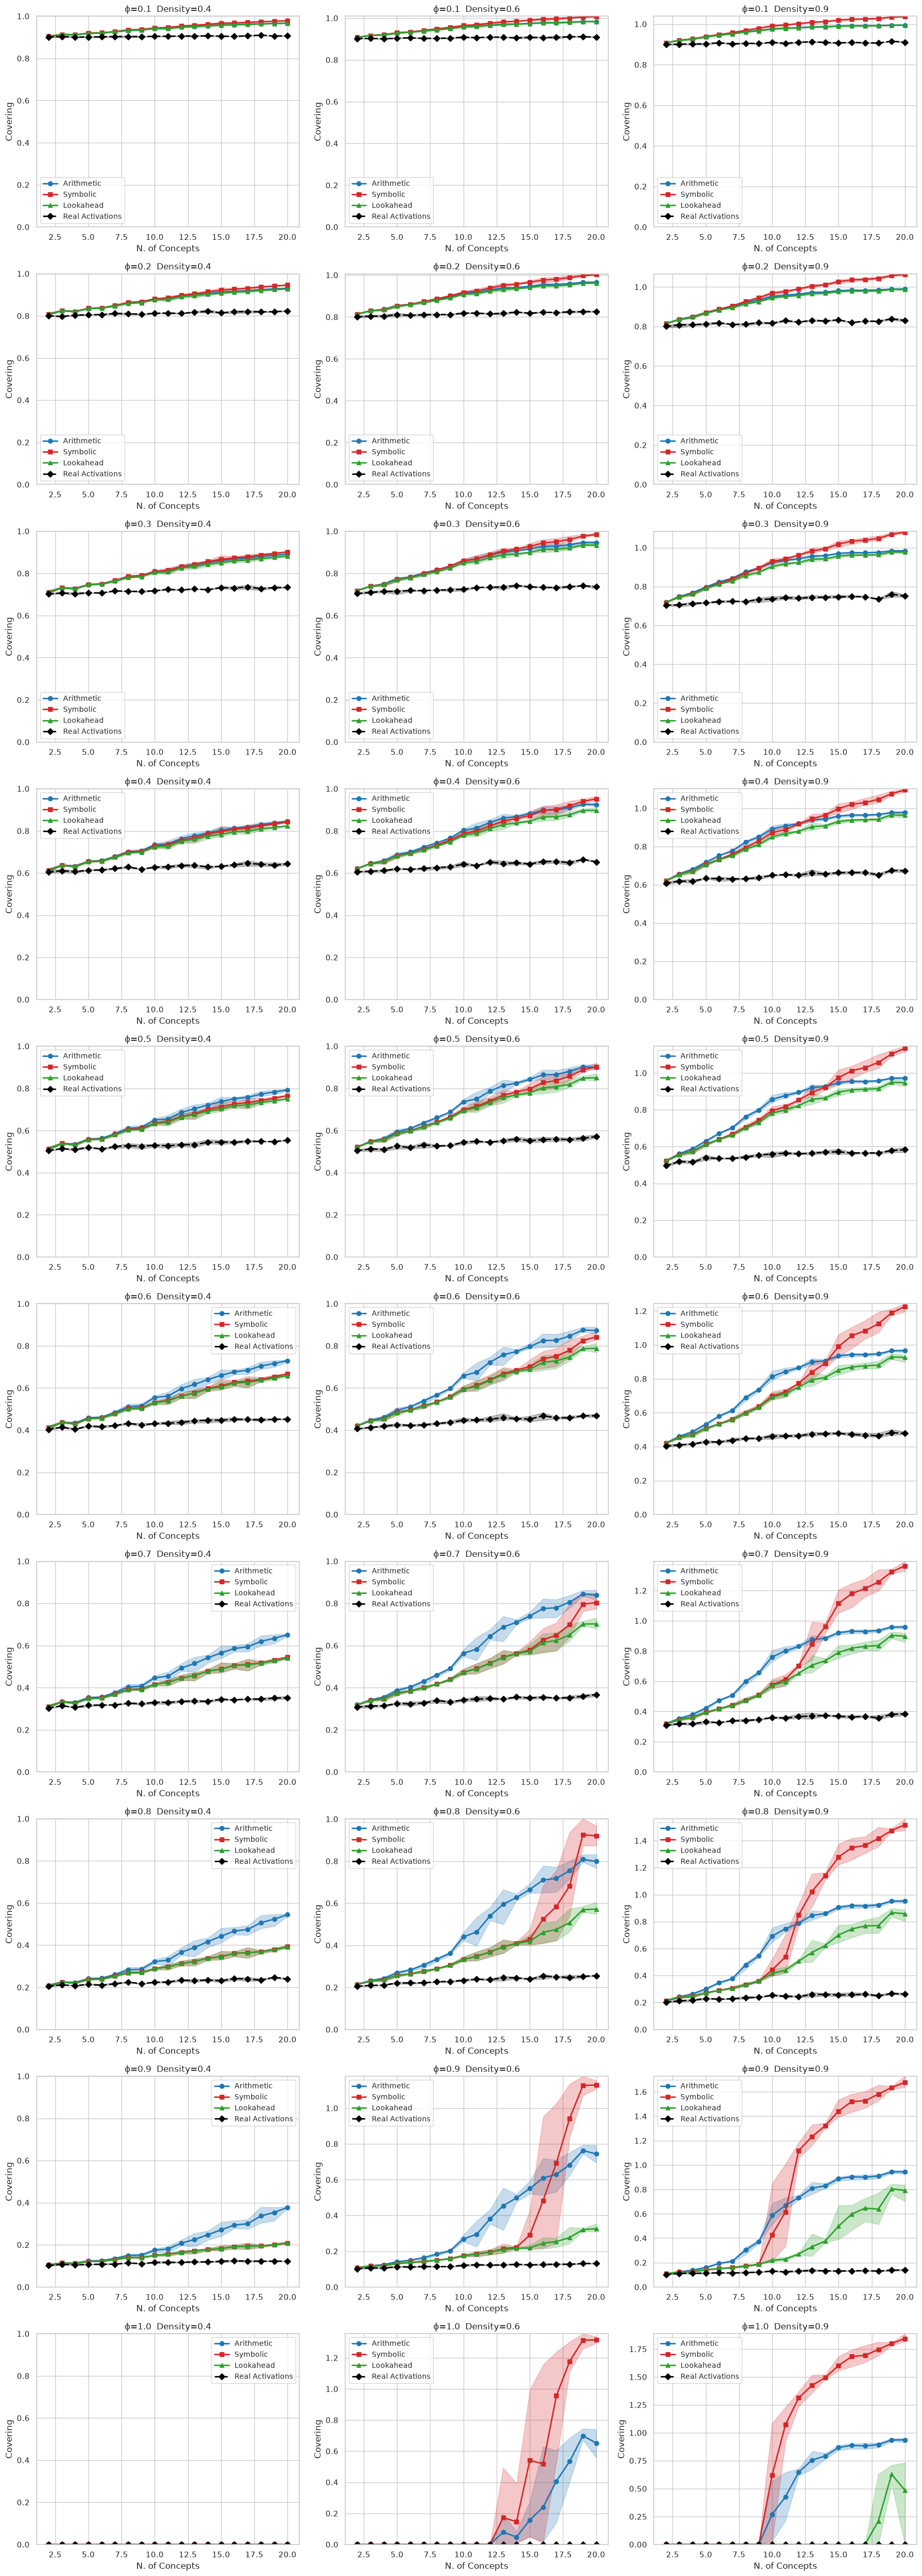

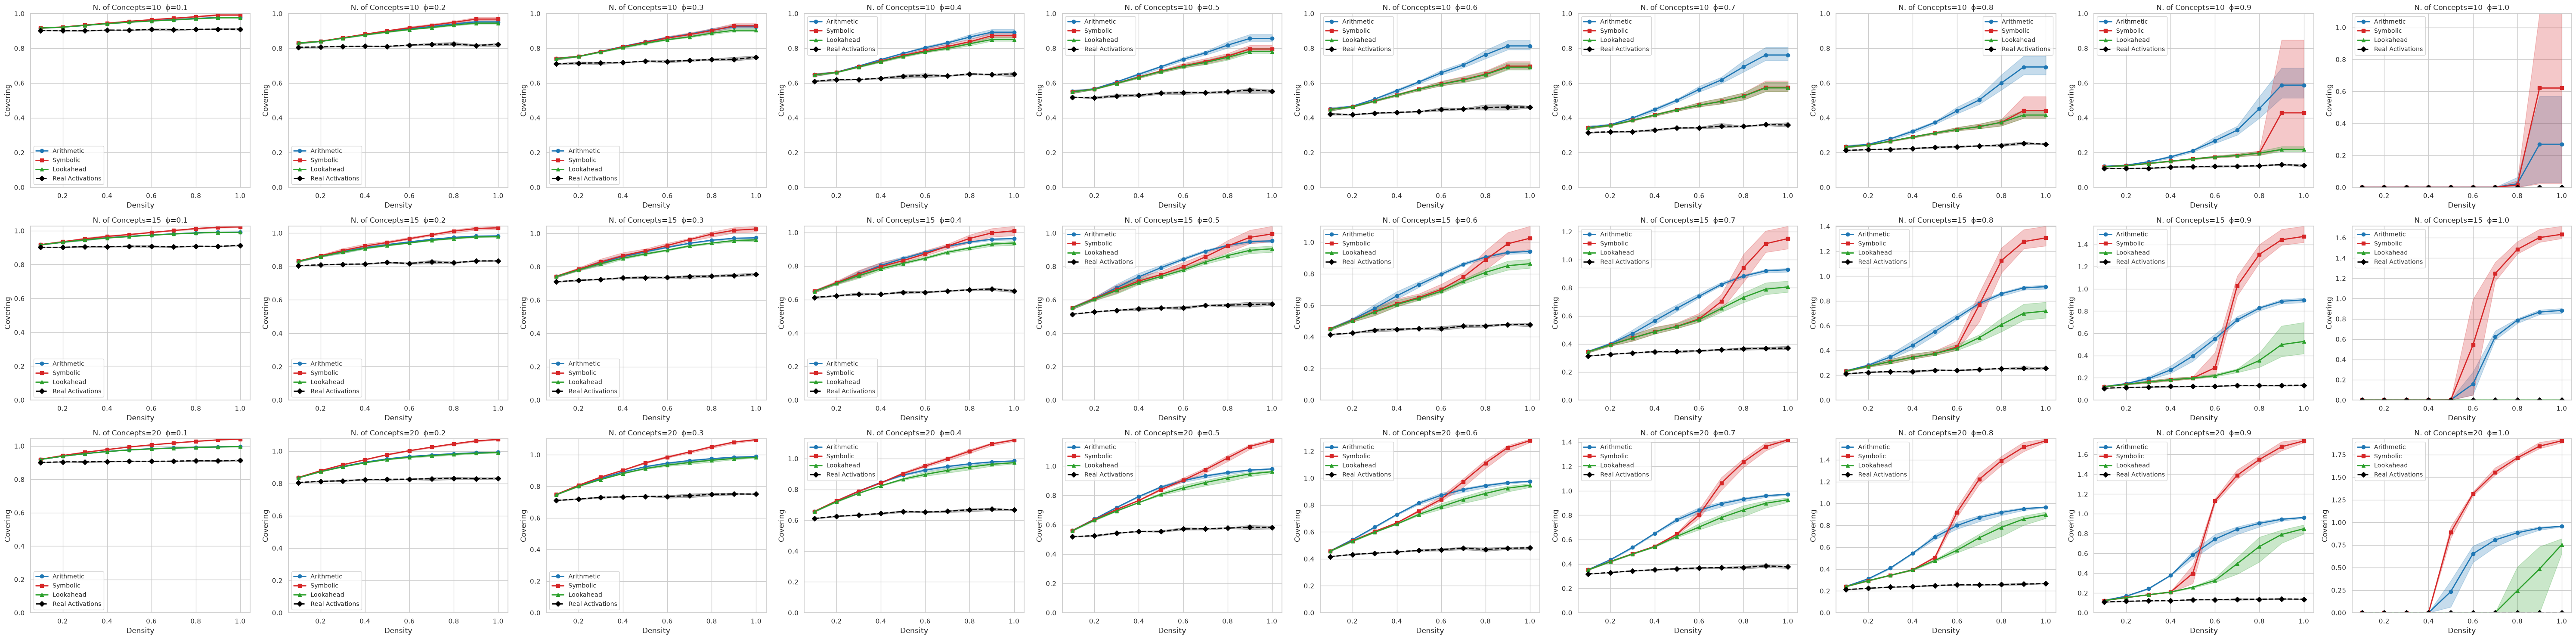

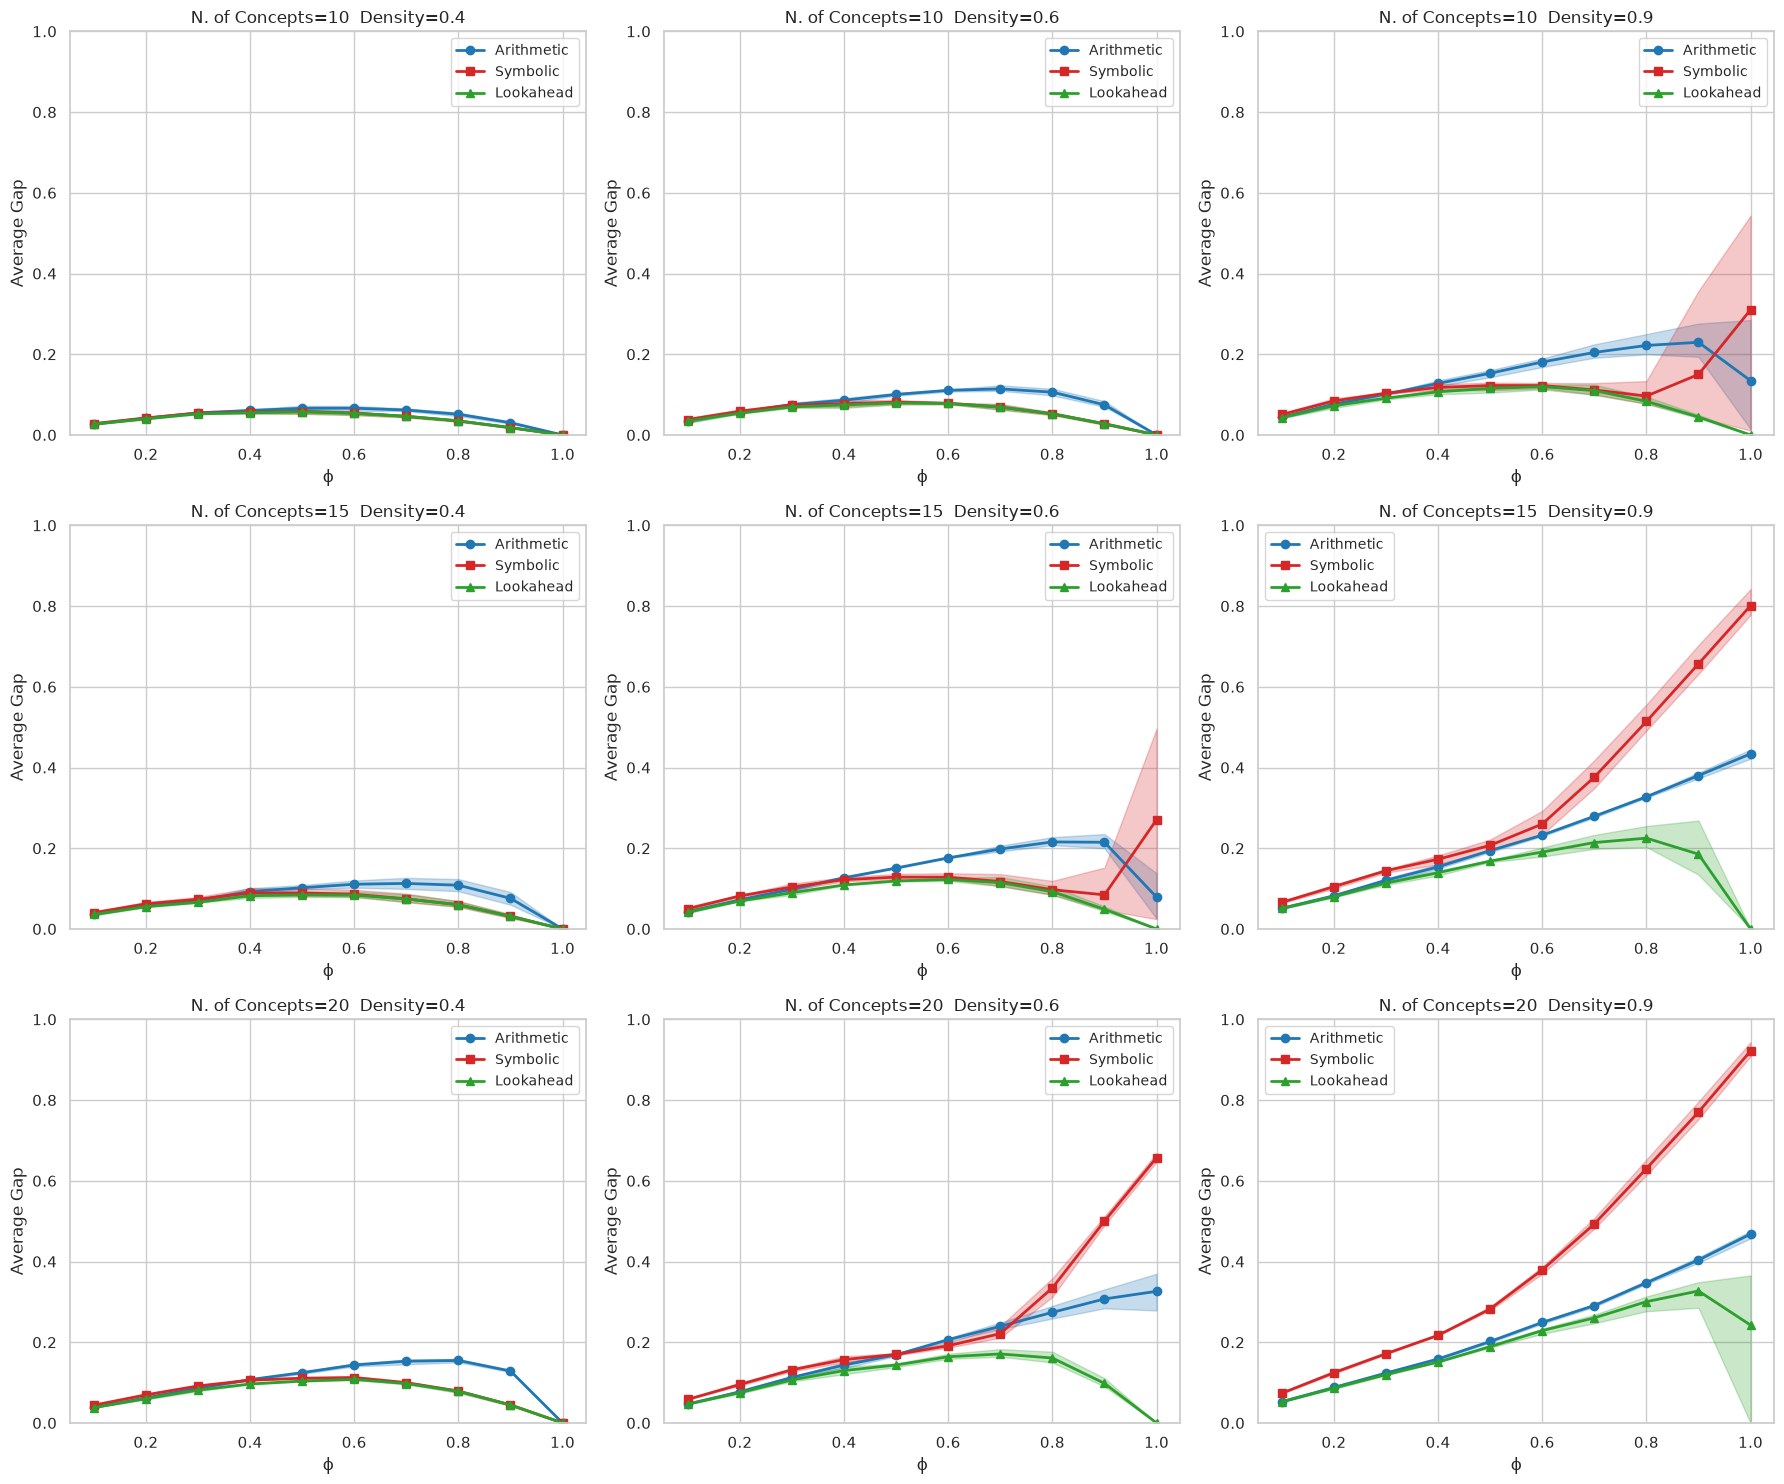

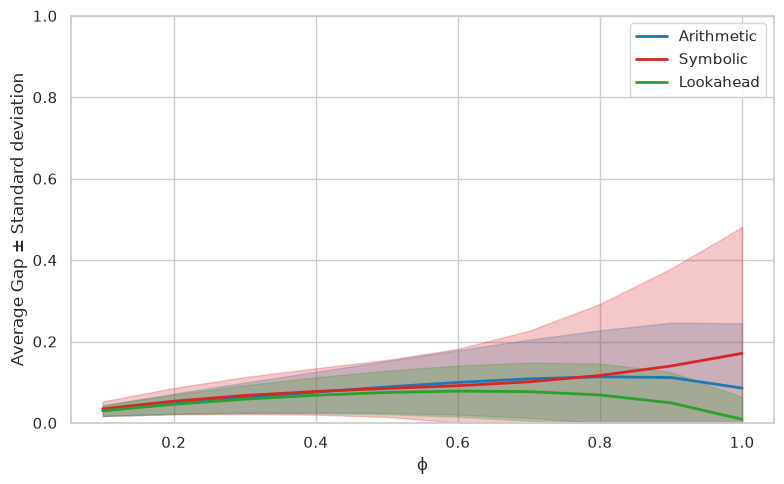

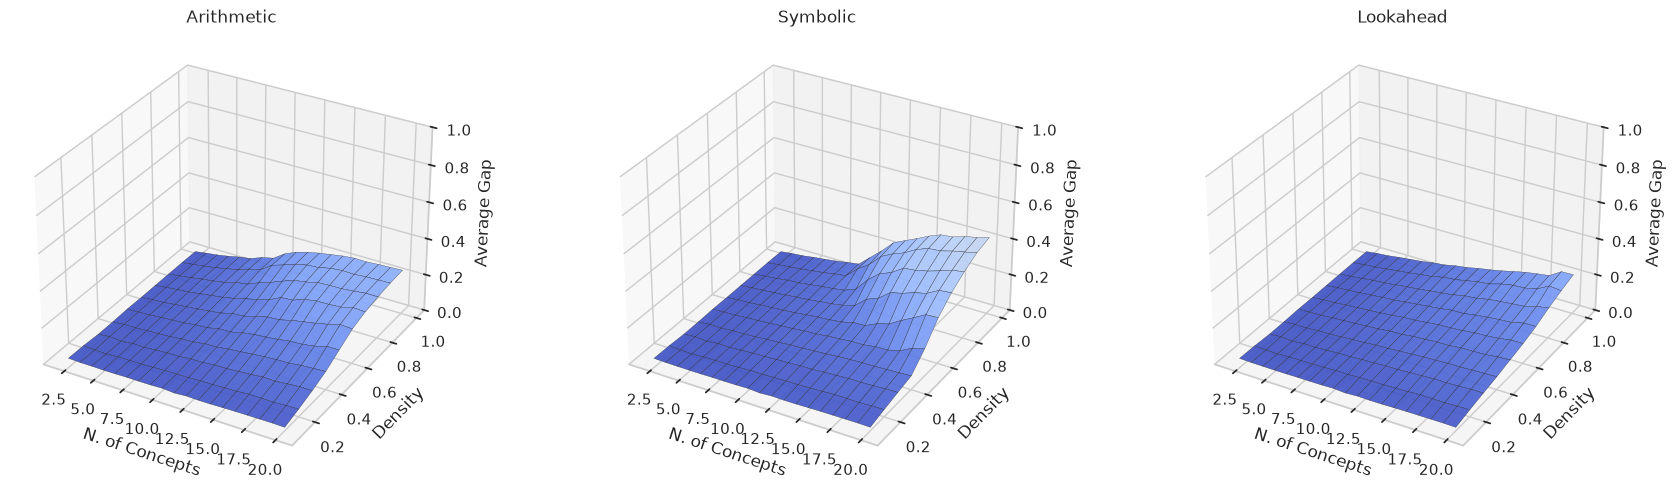

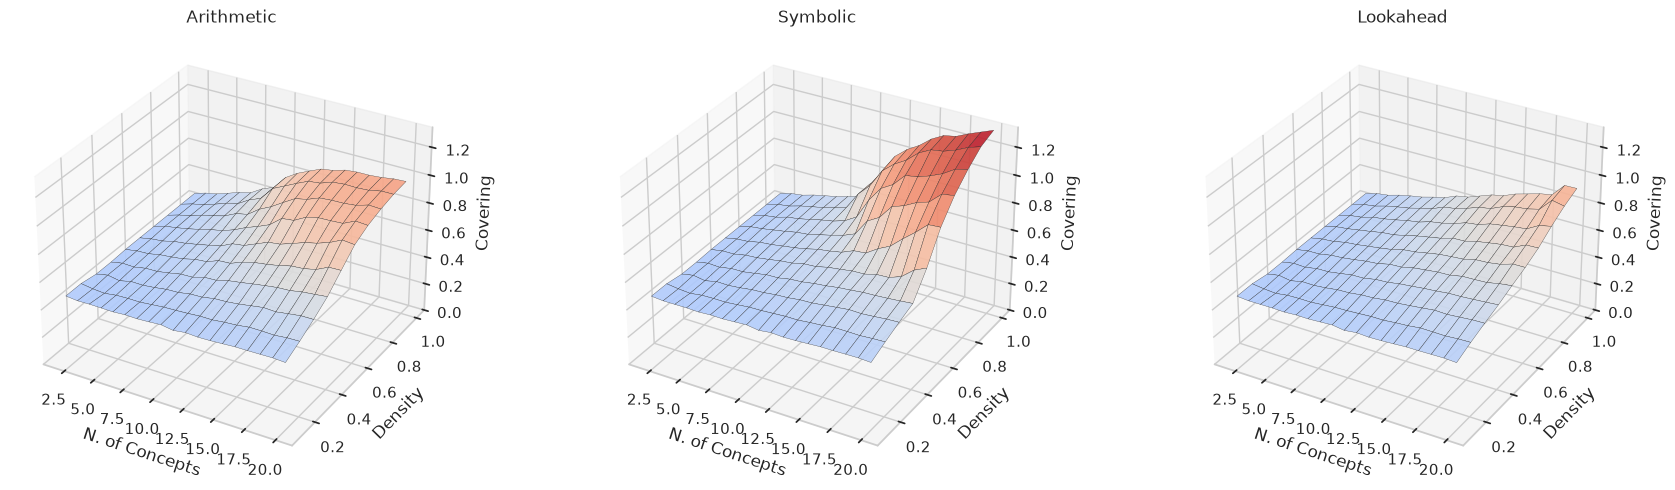

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

sns.set(style="whitegrid")

PLOT_METHODS = list(METHOD_ORDER)
if "sampled_covering" in dataframe.columns:
    PLOT_METHODS += ["sampled"]

# ---------- Textos de las gráficas (labels) ----------
METHODS_LABELS = {
    "arithmetic": "Arithmetic",
    "symbolic": "Symbolic",
    "lookahead": "Lookahead",
    "sampled": "Real Activations",
}
VAR_LABELS = {
    "phi": "ϕ",
    "n_concepts": "N. of Concepts",
    "density": "Density",
}
METRIC_LABELS = {
    "covering": "Covering",
    "average_gap": "Average Gap",
}
GAP_STD_PHI_LABEL = "Average Gap ± Standard deviation"

# ---------- Estilos de las líneas ----------
METHODS_COLORS = {
    "arithmetic": "#1f77b4",
    "symbolic": "#d62728",
    "lookahead": "#2ca02c",
    "sampled": "black",
}
METHODS_MARKERS = {
    "arithmetic": "o",
    "symbolic": "s",
    "lookahead": "^",
    "sampled": "D",
}
METHODS_LINESTYLE = {"sampled": "--"}

# Filtros opcionales para los grids de subplots (None = todos)
GRID_PHI = None
GRID_N_CONCEPTS = None
GRID_DENSITY = None
# Filtro adicional para las primeras gráficas 2D; None muestra todos los conceptos.
FIRST_PLOTS_N_CONCEPTS = [10, 15, 20]
FIRST_PLOTS_DENSITIES = [0.4, 0.6, 0.9]

# Qué graficar (True/False)
PLOT_COVERING_VS = ["phi", "n_concepts", "density"]
PLOT_GAP_VS = ["phi"]
PLOT_GAP_STD_PHI = True
PLOT_SURFACES = True

# Eje y (2D) desde 0 hasta max(1, valor máximo).
PLOT_Y_FROM_ZERO = True

# Eje de altura (3D) desde 0 hasta max(1, valor máximo) y colores del mapa
# normalizados a esa misma escala: 0 -> azul, 1 o más -> rojo.
PLOT_Z_FROM_ZERO = True

df = pd.read_csv(CSV_FILE)


def melt_metric(dframe: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Formato largo: (uuid, n_concepts, density, phi, method, value)."""
    cols = {
        f"{m}_{metric}": m for m in PLOT_METHODS if f"{m}_{metric}" in dframe.columns
    }
    df_long = dframe.melt(
        id_vars=["uuid", "n_concepts", "density", "phi"],
        value_vars=list(cols),
        var_name="method",
        value_name="value",
    )
    df_long["method"] = df_long["method"].str.replace(f"_{metric}", "", regex=False)
    for col in ["phi", "value", "density", "n_concepts"]:
        df_long[col] = pd.to_numeric(df_long[col], errors="coerce")
    return df_long


def summarize(df_long: pd.DataFrame) -> pd.DataFrame:
    """Media/min/max de cada método por (n_concepts, density, phi)."""
    return (
        df_long.groupby(["n_concepts", "density", "phi", "method"], dropna=False)[
            "value"
        ]
        .agg(mean="mean", min="min", max="max")
        .reset_index()
    )


def filtered(df_stats: pd.DataFrame) -> pd.DataFrame:
    """Aplica los filtros GRID_* opcionales."""
    out = df_stats
    if GRID_PHI is not None:
        out = out[out["phi"].isin(GRID_PHI)]
    if GRID_N_CONCEPTS is not None:
        out = out[out["n_concepts"].isin(GRID_N_CONCEPTS)]
    if GRID_DENSITY is not None:
        out = out[out["density"].isin(GRID_DENSITY)]
    return out


def ylim_from_zero(ax: plt.Axes, values: pd.Series) -> None:
    """Eje y de 0 a max(1, máximo de values)."""
    if not PLOT_Y_FROM_ZERO:
        return
    ymax = max(1.0, float(values.max()))
    ax.set_ylim(0, ymax)


def plot_vs(
    df_stats: pd.DataFrame,
    x_col: str,
    row_col: str,
    col_col: str,
    metric: str,
    legend_loc: str = "best",
) -> None:
    """Subplots min-max por método: filas = row_col, columnas = col_col, eje x = x_col.

    Los textos (eje x, títulos, ylabel) salen de VAR_LABELS y METRIC_LABELS.
    """
    stats = filtered(df_stats)
    grid_stats = stats
    if FIRST_PLOTS_N_CONCEPTS is not None and (
        row_col == "n_concepts" or col_col == "n_concepts"
    ):
        grid_stats = grid_stats[grid_stats["n_concepts"].isin(FIRST_PLOTS_N_CONCEPTS)]
    if FIRST_PLOTS_DENSITIES is not None and (
        row_col == "density" or col_col == "density"
    ):
        grid_stats = grid_stats[grid_stats["density"].isin(FIRST_PLOTS_DENSITIES)]
    row_vals = np.sort(grid_stats[row_col].unique())
    col_vals = np.sort(grid_stats[col_col].unique())
    if len(row_vals) == 0 or len(col_vals) == 0:
        print("Sin datos para graficar.")
        return

    xlabel = VAR_LABELS.get(x_col, x_col)
    ylabel = METRIC_LABELS.get(metric, metric)

    fig, axes = plt.subplots(
        len(row_vals),
        len(col_vals),
        figsize=(6 * len(col_vals), 5 * len(row_vals)),
        squeeze=False,
    )
    for i, rv in enumerate(row_vals):
        for j, cv in enumerate(col_vals):
            ax = axes[i, j]
            sub = stats[(stats[row_col] == rv) & (stats[col_col] == cv)]
            if sub.empty:
                ax.axis("off")
                continue
            for m in PLOT_METHODS:
                df_m = sub[sub["method"] == m].sort_values(x_col)
                if df_m.empty:
                    continue
                ax.fill_between(
                    df_m[x_col],
                    df_m["min"],
                    df_m["max"],
                    alpha=0.25,
                    color=METHODS_COLORS.get(m),
                )
                ax.plot(
                    df_m[x_col],
                    df_m["mean"],
                    label=METHODS_LABELS.get(m, m),
                    color=METHODS_COLORS.get(m),
                    marker=METHODS_MARKERS.get(m),
                    linestyle=METHODS_LINESTYLE.get(m, "-"),
                    linewidth=2,
                )
            ax.set_title(
                f"{VAR_LABELS.get(row_col, row_col)}={rv}  "
                f"{VAR_LABELS.get(col_col, col_col)}={cv}"
            )
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ylim_from_zero(ax, sub[["mean", "min", "max"]].max(axis=1))
            ax.legend(loc=legend_loc, fontsize="small")
    plt.tight_layout()
    plt.show()


def surface3d(df_stats: pd.DataFrame, metric: str) -> None:
    """Superficie 3D por método: valor medio vs (n_concepts, density).

    Escala de colores y eje de altura: 0 -> azul, 1 o más -> rojo.
    """
    stats = filtered(df_stats)
    methods = [m for m in PLOT_METHODS if m in stats["method"].unique()]
    if metric == "covering" and not SHOW_SAMPLED_3D:
        methods = [m for m in methods if m != "sampled"]
    elif metric == "covering" and "sampled" in methods:
        methods = ["sampled"] + [m for m in methods if m != "sampled"]
    if len(methods) == 0:
        print("Sin datos para graficar 3D.")
        return

    zlabel = METRIC_LABELS.get(metric, metric)
    xlabel = VAR_LABELS.get("n_concepts", "n_concepts")
    ylabel = VAR_LABELS.get("density", "density")

    # Superficies de todos los métodos para calcular el máximo global
    surfaces = {}
    for m in methods:
        df_m = stats[stats["method"] == m]
        pivot = df_m.groupby(["n_concepts", "density"])["mean"].mean().reset_index()
        nc = np.sort(pivot["n_concepts"].unique())
        den = np.sort(pivot["density"].unique())
        X, Y = np.meshgrid(nc, den)
        Z = np.full_like(X, np.nan, dtype=float)
        for i, d in enumerate(den):
            for j, n in enumerate(nc):
                val = pivot[(pivot["n_concepts"] == n) & (pivot["density"] == d)][
                    "mean"
                ]
                if not val.empty:
                    Z[i, j] = val.values[0]
        surfaces[m] = (X, Y, Z)

    # Tope de la escala: 0 .. max(1, máximo global)
    z_axis_top = max(1.0, float(np.nanmax([surfaces[m][2] for m in methods])))

    fig = plt.figure(figsize=(6 * len(methods), 5))
    for idx, m in enumerate(methods, 1):
        X, Y, Z = surfaces[m]
        ax = fig.add_subplot(1, len(methods), idx, projection="3d")
        ax.plot_surface(
            X,
            Y,
            Z,
            cmap=cm.coolwarm,
            edgecolor="k",
            linewidth=0.2,
            alpha=0.9,
            vmin=0,
            vmax=z_axis_top,
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_zlabel(zlabel)
        if PLOT_Z_FROM_ZERO:
            ax.set_zlim(0, z_axis_top)
        ax.set_title(METHODS_LABELS.get(m, m))
    plt.tight_layout()
    plt.show()


# ==============================
# Generación de gráficas
# ==============================
covering_stats = summarize(melt_metric(df, "covering"))
gap_stats = summarize(melt_metric(df, "average_gap"))

# Cubrimiento promedio (con min-max) variando phi, n_concepts y density
for x_col in PLOT_COVERING_VS:
    if x_col == "phi":
        plot_vs(covering_stats, "phi", "n_concepts", "density", "covering")
    elif x_col == "n_concepts":
        plot_vs(covering_stats, "n_concepts", "phi", "density", "covering")
    else:
        plot_vs(covering_stats, "density", "n_concepts", "phi", "covering")

# Desviación (gap) variando phi
for x_col in PLOT_GAP_VS:
    if x_col == "phi":
        plot_vs(gap_stats, "phi", "n_concepts", "density", "average_gap")

# Promedio ± desviación estándar del gap por método, variando phi
if PLOT_GAP_STD_PHI:
    gap_long = melt_metric(df, "average_gap")
    gap_by_phi = (
        gap_long.groupby(["phi", "method"], dropna=False)["value"]
        .agg(mean="mean", std="std")
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    for m in [m for m in PLOT_METHODS if m != "sampled"]:
        df_m = gap_by_phi[gap_by_phi["method"] == m]
        if df_m.empty:
            continue
        ax.plot(
            df_m["phi"],
            df_m["mean"],
            label=METHODS_LABELS.get(m, m),
            color=METHODS_COLORS.get(m),
            linewidth=2,
        )
        ax.fill_between(
            df_m["phi"],
            df_m["mean"] - df_m["std"],
            df_m["mean"] + df_m["std"],
            alpha=0.25,
            color=METHODS_COLORS.get(m),
        )
    ax.set_xlabel(VAR_LABELS.get("phi", "phi"))
    ax.set_ylabel(GAP_STD_PHI_LABEL)
    ylim_from_zero(ax, gap_by_phi["mean"] + gap_by_phi["std"])
    ax.legend()
    plt.tight_layout()
    plt.show()

# Superficies 3D por método
if PLOT_SURFACES:
    surface3d(gap_stats, "average_gap")
    surface3d(covering_stats, "covering")

## Lookahead completo: rangos finales más ajustados

Comprueba la propiedad clave del método lookahead con la cadena hasta el final (`k = max_iters`): para cada configuración `(uuid, phi)`, compara el **intervalo final** (última iteración) de lookahead con el de cada uno de los demás métodos.

- **`contained`**: el rango final de lookahead está completamente contenido en el del método comparado (`is_inside_state`, con tolerancia `EPSILON`).
- **`tighter`**: contenido **y** estrictamente más estrecho (anchura total menor, es decir, realmente más ajustado).

Las series de intervalos por iteración las guarda el bucle de comparación en `STATES_DIR` (un `.npz` por configuración, con todos los métodos). Este análisis lee esos archivos y toma `[-1]` (el intervalo final) **sin recalcular** los métodos.


In [44]:
# Análisis de contención leyendo los intervalos cacheados por el bucle
# (un .npz por configuración en STATES_DIR), sin recalcular los métodos.

import glob


def _load_state(data: np.lib.npyio.NpzFile, name: str) -> torch.Tensor:
    """Devuelve el intervalo final (última iteración) del método name."""
    series = torch.from_numpy(data[name]).to(device)
    return series[-1]


if not os.path.isdir(STATES_DIR):
    raise FileNotFoundError(
        f"{STATES_DIR} no existe: corre primero el bucle de comparación."
    )

paths = sorted(glob.glob(os.path.join(STATES_DIR, "*.npz")))
if not paths:
    raise FileNotFoundError(f"No hay archivos .npz en {STATES_DIR}.")

comparisons = []
skipped = 0
for path in tqdm(paths):
    base = os.path.basename(path)[: -len(".npz")]
    uuid, phi_str = base.rsplit("_phi", 1)
    phi = float(phi_str)

    with np.load(path) as data:
        if not all(m in data for m in METHOD_ORDER):
            print(f"Advertencia: {base} no contiene todos los métodos, se omite")
            skipped += 1
            continue
        last = {name: _load_state(data, name) for name in METHOD_ORDER}

    density = next(s["density"] for s in samples if s["uuid"] == uuid)
    n_concepts = last["arithmetic"].shape[1]
    width_lookahead = float((last["lookahead"][1] - last["lookahead"][0]).sum())

    for name in METHOD_ORDER:
        if name == "lookahead":
            continue
        other = last[name]
        contained = is_inside_state(last["lookahead"], other, tolerance=EPSILON)
        width_other = float((other[1] - other[0]).sum())
        tighter = contained and width_lookahead < width_other - EPSILON
        comparisons.append(
            {
                "uuid": uuid,
                "n_concepts": n_concepts,
                "density": density,
                "phi": phi,
                "method": name,
                "width_lookahead": width_lookahead,
                "width_other": width_other,
                "contained": bool(contained),
                "tighter": bool(tighter),
            }
        )

if skipped:
    print(f"Archivos omitidos por incompletos: {skipped}")

df_containment = pd.DataFrame(comparisons)
print(
    f"Configuraciones evaluadas: {df_containment['uuid'].nunique()} "
    f"({len(df_containment)} comparaciones lookahead vs otro método)"
)

100%|██████████| 5700/5700 [00:26<00:00, 212.86it/s]


Configuraciones evaluadas: 570 (11400 comparaciones lookahead vs otro método)


In [45]:
# Resumen: ¿el rango final de lookahead está contenido en el de cada método?

summary = df_containment.groupby("method").agg(
    n_total=("contained", "count"),
    n_contained=("contained", "sum"),
    n_tighter=("tighter", "sum"),
    mean_width_lookahead=("width_lookahead", "mean"),
    mean_width_other=("width_other", "mean"),
)
summary["frac_contained"] = summary["n_contained"] / summary["n_total"]
summary["frac_tighter"] = summary["n_tighter"] / summary["n_total"]
summary = summary.round(4)
display(summary)

not_contained = df_containment[~df_containment["contained"]]
if not_contained.empty:
    print(
        "Lookahead está contenido en TODOS los demás métodos en todas las configuraciones."
    )
else:
    print(f"Casos en que lookahead NO está contenido: {len(not_contained)}")
    display(not_contained[["uuid", "n_concepts", "density", "phi", "method"]])

# Desglose: nº de configuraciones en que lookahead está contenido, por método y n_concepts
breakdown = (
    df_containment.groupby(["method", "n_concepts"], dropna=False)
    .agg(n_contained=("contained", "sum"), n_tighter=("tighter", "sum"))
    .reset_index()
)
print("\nContenido (lookahead ⊆ método) por método y n_concepts:")
display(breakdown.pivot(index="method", columns="n_concepts", values="n_contained"))
print("\nEstrictamente más ajustado por método y n_concepts:")
display(breakdown.pivot(index="method", columns="n_concepts", values="n_tighter"))

,n_total,n_contained,n_tighter,mean_width_lookahead,mean_width_other,frac_contained,frac_tighter
method,,,,,,,
arithmetic,5700,5700,5105,6.7277,7.4925,1.0,0.8956
symbolic,5700,5700,4569,6.7277,7.9626,1.0,0.8016


Lookahead está contenido en TODOS los demás métodos en todas las configuraciones.

Contenido (lookahead ⊆ método) por método y n_concepts:


n_concepts,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
method,,,,,,,,,,,,,,,,,,,
arithmetic,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300
symbolic,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300



Estrictamente más ajustado por método y n_concepts:


n_concepts,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
method,,,,,,,,,,,,,,,,,,,
arithmetic,198,224,243,225,261,270,275,267,274,275,286,278,288,287,291,290,291,291,291
symbolic,134,198,155,206,186,224,210,238,249,267,261,269,277,278,281,280,283,287,286


## Encogimiento de las series

Una serie se considera que cumple el **Teorema del Encogimiento Débil** si el intervalo de cada iteración está completamente contenido en el de la iteración anterior:

```
states[i] ⊆ states[i-1]  para todo i = 1 .. max_iters
```

Es decir, los intervalos nunca crecen: se contraen (o se estabilizan) iteración a iteración. Una serie **encoge estrictamente** si, además, la anchura del intervalo disminuye en cada iteración (`series_is_nested` / `series_is_strictly_contracting`, con tolerancia `EPSILON`). Se lee de los `.npz` cacheados en `STATES_DIR` (guardados por el bucle), sin recalcular nada. Un intervalo con `NaN` cuenta como no anidado.

In [46]:
# Convergencia de las series: para cada configuración y método,
# ¿el intervalo de cada iteración está contenido en el de la anterior?
# (anidada) y ¿la anchura disminuye en cada iteración? (estrictamente contrayente).


def _to_state_tensor(series: np.ndarray) -> torch.Tensor:
    """Convierte una serie guardada en .npz a tensor en device."""
    return torch.from_numpy(series).to(device)


if not os.path.isdir(STATES_DIR):
    raise FileNotFoundError(
        f"{STATES_DIR} no existe: corre primero el bucle de comparación."
    )

paths = sorted(glob.glob(os.path.join(STATES_DIR, "*.npz")))
if not paths:
    raise FileNotFoundError(f"No hay archivos .npz en {STATES_DIR}.")

convergence_rows = []
skipped = 0
for path in tqdm(paths):
    base = os.path.basename(path)[: -len(".npz")]
    uuid, phi_str = base.rsplit("_phi", 1)
    phi = float(phi_str)

    with np.load(path) as data:
        if not all(m in data for m in METHOD_ORDER):
            print(f"Advertencia: {base} no contiene todos los métodos, se omite")
            skipped += 1
            continue
        for name in METHOD_ORDER:
            series = _to_state_tensor(data[name])
            convergence_rows.append(
                {
                    "uuid": uuid,
                    "phi": phi,
                    "method": name,
                    "n_iters": series.shape[0],
                    "nested": series_is_nested(series, tolerance=EPSILON),
                    "strictly_contracting": series_is_strictly_contracting(
                        series, epsilon=EPSILON
                    ),
                }
            )

df_convergence = pd.DataFrame(convergence_rows)
if skipped:
    print(f"Archivos omitidos por incompletos: {skipped}")

# Cuántas series convergen por método (anidadas y estrictamente contrayentes)
summary = (
    df_convergence.groupby("method")
    .agg(
        n_total=("nested", "count"),
        n_nested=("nested", "sum"),
        n_strictly_contracting=("strictly_contracting", "sum"),
    )
    .reset_index()
)
summary["frac_nested"] = (summary["n_nested"] / summary["n_total"]).round(4)
summary["frac_strict"] = (summary["n_strictly_contracting"] / summary["n_total"]).round(
    4
)
display(summary)

# Desglose por método y n_concepts (series anidadas)
uuid_n = {s["uuid"]: s["n_concepts"] for s in samples}
df_convergence["n_concepts"] = df_convergence["uuid"].map(uuid_n)
print("\nSeries anidadas por método y n_concepts:")
display(
    df_convergence.pivot_table(
        index="method", columns="n_concepts", values="nested", aggfunc="sum"
    )
)

100%|██████████| 5700/5700 [02:03<00:00, 46.18it/s]


,method,n_total,n_nested,n_strictly_contracting,frac_nested,frac_strict
0,arithmetic,5700,5700,104,1.0000,0.0182
1,lookahead,5700,5699,99,0.9998,0.0174
2,symbolic,5700,2287,162,0.4012,0.0284



Series anidadas por método y n_concepts:


n_concepts,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
method,,,,,,,,,,,,,,,,,,,
arithmetic,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300
lookahead,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,299
symbolic,300,300,300,300,250,160,110,70,100,60,50,57,60,30,40,40,20,20,20


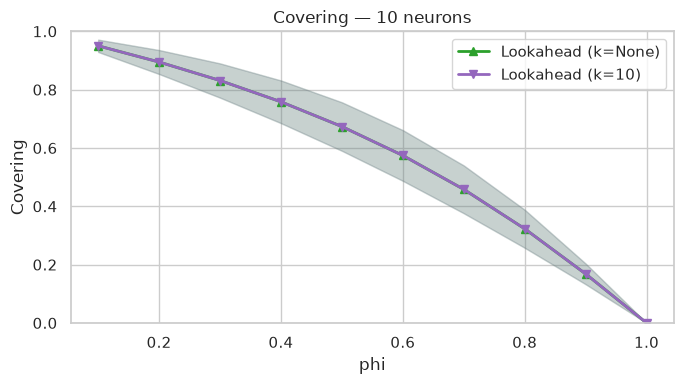

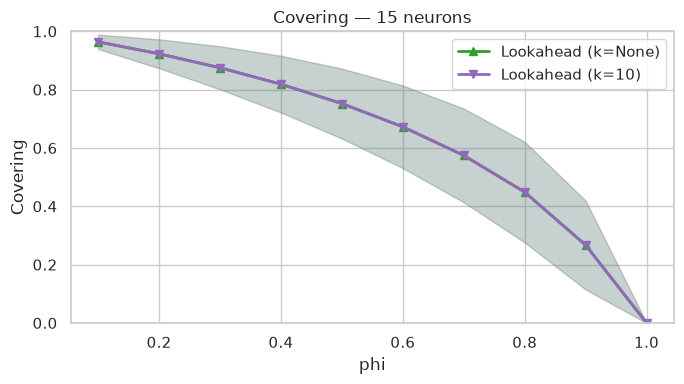

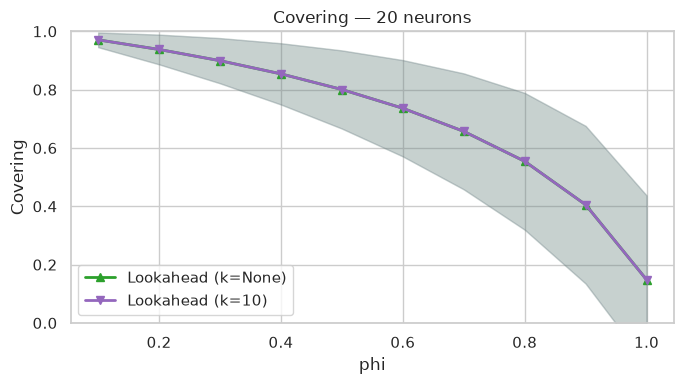

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_cmp = pd.read_csv("resultados.csv")
df_cmp = df_cmp.dropna(subset=["lookahead_covering", "lookahead_10_covering"])

methods_cmp = {
    "lookahead": ("Lookahead (k=None)", "#2ca02c", "^"),
    "lookahead_10": ("Lookahead (k=10)", "#9467bd", "v"),
}

target_nc = [10, 15, 20]

for nc in target_nc:
    sub = df_cmp[df_cmp["n_concepts"] == nc]
    if sub.empty:
        print(f"Sin datos para n_concepts={nc}")
        continue

    fig, ax = plt.subplots(figsize=(7, 4))
    for key, (label, color, marker) in methods_cmp.items():
        g = sub.groupby("phi")[f"{key}_covering"].agg(["mean", "std"]).reset_index()
        ax.plot(
            g["phi"],
            g["mean"],
            marker=marker,
            color=color,
            linewidth=2,
            label=label,
        )
        ax.fill_between(
            g["phi"],
            g["mean"] - g["std"],
            g["mean"] + g["std"],
            alpha=0.2,
            color=color,
        )
    ax.set_title(f"Covering — {nc} neurons")
    ax.set_xlabel("phi")
    ax.set_ylabel("Covering")
    ax.set_ylim(
        0,
        max(
            1.0, float(sub[["lookahead_covering", "lookahead_10_covering"]].max().max())
        ),
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

In [48]:
import pandas as pd
import numpy as np
from IPython.display import display

df_conv = pd.read_csv("resultados.csv")

methods_to_check = [m for m in METHOD_ORDER if f"{m}_converged_at" in df_conv.columns]

results = []
for m in methods_to_check:
    col = f"{m}_converged_at"
    total = len(df_conv)
    converged = df_conv[col].notna().sum()
    not_converged = total - converged
    avg_iter = df_conv.loc[df_conv[col].notna(), col].mean()
    results.append(
        {
            "Método": METHODS_LABELS.get(m, m),
            "Total": total,
            "Converge": int(converged),
            "No converge": int(not_converged),
            "Frac. converge": round(converged / total, 4) if total > 0 else 0,
            "Iter. promedio": round(avg_iter, 2) if pd.notna(avg_iter) else None,
        }
    )

df_summary = pd.DataFrame(results)
print(
    "Convergencia por método (ancho del intervalo < EPSILON en todas las componentes):"
)
display(df_summary)

if "lookahead_10_converged_at" in df_conv.columns:
    mask_both = (
        df_conv["lookahead_converged_at"].notna()
        & df_conv["lookahead_10_converged_at"].notna()
    )
    mask_la_only = (
        df_conv["lookahead_converged_at"].notna()
        & df_conv["lookahead_10_converged_at"].isna()
    )
    mask_l10_only = (
        df_conv["lookahead_converged_at"].isna()
        & df_conv["lookahead_10_converged_at"].notna()
    )
    mask_neither = (
        df_conv["lookahead_converged_at"].isna()
        & df_conv["lookahead_10_converged_at"].isna()
    )
    print(f"\nComparación lookahead vs lookahead_10:")
    print(f"  Ambos convergen:          {mask_both.sum()}")
    print(f"  Solo lookahead converge:  {mask_la_only.sum()}")
    print(f"  Solo lookahead_10 converge: {mask_l10_only.sum()}")
    print(f"  Ninguno converge:         {mask_neither.sum()}")

if (
    "lookahead_converged_at" in df_conv.columns
    and "arithmetic_converged_at" in df_conv.columns
):
    la = df_conv["lookahead_converged_at"]
    ar = df_conv["arithmetic_converged_at"]
    mask_both = la.notna() & ar.notna()
    mask_la_only = la.notna() & ar.isna()
    mask_ar_only = la.isna() & ar.notna()
    mask_neither = la.isna() & ar.isna()
    print(f"\nComparación lookahead vs arithmetic:")
    print(f"  Ambos convergen:          {mask_both.sum()}")
    print(f"  Solo lookahead converge:  {mask_la_only.sum()}")
    print(f"  Solo arithmetic converge: {mask_ar_only.sum()}")
    print(f"  Ninguno converge:         {mask_neither.sum()}")

print("\nMétodo | Frac. converge | Iter. promedio")
print("-" * 50)
for _, row in df_summary.iterrows():
    print(
        f"{row['Método']:20s} | {row['Frac. converge']:>12.2%} | {str(row['Iter. promedio']):>15s}"
    )

Convergencia por método (ancho del intervalo < EPSILON en todas las componentes):


,Método,Total,Converge,No converge,Frac. converge,Iter. promedio
0,Arithmetic,5700,365,5335,0.0640,15.53
1,Symbolic,5700,372,5328,0.0653,14.46
2,Lookahead,5700,543,5157,0.0953,15.48



Comparación lookahead vs lookahead_10:
  Ambos convergen:          543
  Solo lookahead converge:  0
  Solo lookahead_10 converge: 0
  Ninguno converge:         5157

Comparación lookahead vs arithmetic:
  Ambos convergen:          365
  Solo lookahead converge:  178
  Solo arithmetic converge: 0
  Ninguno converge:         5157

Método | Frac. converge | Iter. promedio
--------------------------------------------------
Arithmetic           |        6.40% |           15.53
Symbolic             |        6.53% |           14.46
Lookahead            |        9.53% |           15.48


## Test estadístico — mejora del lookahead frente a un margen de relevancia

Para cada configuración `(uuid, phi)` comparamos el **lookahead** contra **arithmetic** y contra **symbolic** usando dos métricas escalares pareadas:

1. **Average gap** (columnas del CSV) — el gap promedio predicho (gap menor ⇒ cotas más ajustadas).
2. **Covering** (Def. 9 del paper, desde los `.npz`) — promedio del cociente (longitud del intervalo factible)/(longitud del espacio inducido) por neurón en la última iteración (covering menor ⇒ más ajustado).

En lugar de probar "¿las diferencias son ≠ 0?" (trivial, ya probado por teorema de dominancia), probamos la afirmación de relevancia práctica:

- Se define la **reducción relativa por caso** (RMD):  `r = (baseline − lookahead) / baseline`.
- Se testea que la reducción **excede un margen** `δ = 0.05` ("al menos 5% más ajustado") mediante el **test de rangos con signo de Wilcoxon unilateral** (`alternative="greater"`): `wilcoxon(r − δ, alternative="greater")`.

Opciones metodológicas (siguiendo recomendaciones de revisión):

- **Empates**: `zero_method="pratt"` — los empates (`r == 0`) se **incluyen** en la distribución nula, en vez de descartarse (conservador, no se infla el resultado).
- **p-valores**: `method="approx"` para que no se saturen a 0; se reporta `log10(p)` cuando `p` es desbordantemente pequeño.
- **Corrección por comparaciones múltiples**: **Holm** (step-down) sobre las 4 comparaciones — más potente que Bonferroni y recomendado por Demšar [7].
- **Estimación de magnitud**: mediana de la reducción relativa con su **IC 95% por bootstrap** (con `n ~ 5700` es el IC el que comunica la magnitud, no el `p`).

El resultado se presenta en una **tabla con una fila por comparación** (sin promediar), con columnas: comparación, métrica, `n (non-tied)`, mediana de la reducción `[IC 95%]`, y `p` unilateral ajustado por Holm.


In [49]:
import numpy as np
import pandas as pd
import torch
import glob
import os
import sys
from scipy.stats import wilcoxon

from core import covering

# Robustez: en caso de ejecutar esta celda aislada, definir el entorno.
if "CSV_FILE" not in globals():
    CSV_FILE = "resultados.csv"
if "STATES_DIR" not in globals():
    STATES_DIR = "estados"


# ============================================================
# Helpers comunes (reutilizados por las celdas 29, 31 y 32)
# ============================================================
DELTA = 0.05  # margen de relevancia práctica (al menos 5% más ajustado)
ALPHA = 0.05


def rmd_rel(baseline: np.ndarray, ours: np.ndarray) -> pd.Series:
    """Reducción relativa por caso r = (baseline - ours) / baseline."""
    base = np.where(np.abs(baseline) < 1e-15, np.nan, baseline)
    return pd.Series((baseline - ours) / base)


def wilcoxon_greater_pratt(r: pd.Series, delta: float = DELTA):
    """Wilcoxon unilateral (greater) contra el margen `delta`, con empates Pratt.

    - `alternative='greater'`: prueba que la reducción relativa EXCEDE delta,
      no sólo que difiere de 0 (que es trivial por teorema).
    - `zero_method='pratt'`: incluye los empates en la distribución nula, en vez
      de descartarlos silenciosamente (conservador, preferido por revisores).
    - `method='approx'`: p-valores finitos con n grande.
    """
    x = r.dropna()
    return wilcoxon(
        x - delta, alternative="greater", zero_method="pratt", method="approx"
    )


def bootstrap_median_ci(
    r: pd.Series, alpha: float = 0.05, B: int = 3000, seed: int = 1
):
    """Mediana de la reducción relativa ± IC 95% por bootstrap (percentil)."""
    rng = np.random.default_rng(seed)
    x = r.dropna().to_numpy()
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    boot = np.array(
        [np.median(rng.choice(x, size=len(x), replace=True)) for _ in range(B)]
    )
    med = np.median(x)
    lo = np.percentile(boot, 100 * alpha / 2)
    hi = np.percentile(boot, 100 * (1 - alpha / 2))
    return float(med), float(lo), float(hi)


def holm_adjust(ps):
    """Corrección de Holm (step-down) sobre una lista de p-valores.

    Más potente que Bonferroni y recomendado por Demšar [7] para comparaciones
    múltiples de clasificadores, coherente con las fuentes citadas.
    """
    order = np.argsort(ps)
    m = len(ps)
    prev = 0.0
    adj = [0.0] * m
    for rank, i in enumerate(order):
        adj[i] = max(prev, ps[i] * (m - rank))
        prev = adj[i]
    return [min(1.0, a) for a in adj]


# ============================================================
# Recopilar reducciones relativas (gap del CSV + covering de los .npz)
# ============================================================
dfr = pd.read_csv(CSV_FILE)

REDUCTIONS: dict[str, pd.Series] = (
    {}
)  # clave -> r (reducción relativa, por configuración)
META: dict[str, dict] = {}  # clave -> metadatos (n_total, n_ties, n_non_tied)

# --- GAP (métricas del CSV) ---
for base in ["arithmetic", "symbolic"]:
    ca, cb = f"{base}_average_gap", "lookahead_average_gap"
    sub = dfr.dropna(subset=[ca, cb])
    r = rmd_rel(sub[ca].to_numpy(), sub[cb].to_numpy())
    key = f"{base}_gap"
    REDUCTIONS[key] = r
    META[key] = {
        "comparacion": f"Lookahead vs {base.capitalize()}",
        "metrica": "RMD (average gap)",
        "n_total": int(len(r)),
        "n_ties": int((r == 0).sum()),
        "n_non_tied": int((r != 0).sum()),
    }

# --- COVERING (recalculado desde los .npz; cubre = Def. 9) ---
_cov: dict[str, list] = {"arithmetic": [], "symbolic": []}
for path in sorted(glob.glob(os.path.join(STATES_DIR, "*.npz"))):
    with np.load(path) as data:
        if not {"arithmetic", "symbolic", "lookahead"}.issubset(data.files):
            continue
        la = covering(torch.from_numpy(data["lookahead"]))
        _cov["arithmetic"].append((covering(torch.from_numpy(data["arithmetic"])), la))
        _cov["symbolic"].append((covering(torch.from_numpy(data["symbolic"])), la))
for base in ["arithmetic", "symbolic"]:
    arr = np.array(_cov[base])
    r = rmd_rel(arr[:, 0], arr[:, 1])
    key = f"{base}_covering"
    REDUCTIONS[key] = r
    META[key] = {
        "comparacion": f"Lookahead vs {base.capitalize()}",
        "metrica": "RMD (covering, Def. 9)",
        "n_total": int(len(r)),
        "n_ties": int((r == 0).sum()),
        "n_non_tied": int((r != 0).sum()),
    }


# ============================================================
# Construir la tabla (una fila por comparación, sin promediar)
# ============================================================
rows = []
for key in [
    "arithmetic_gap",
    "symbolic_gap",
    "arithmetic_covering",
    "symbolic_covering",
]:
    r = REDUCTIONS[key]
    med, lo, hi = bootstrap_median_ci(r)
    res = wilcoxon_greater_pratt(r)
    rows.append(
        {
            "clave": key,
            **META[key],
            "mediana_RMD": med,
            "IC95_lo": lo,
            "IC95_hi": hi,
            "p_greater": float(res.pvalue),
        }
    )

df_tab = pd.DataFrame(rows)
df_tab["log10p"] = np.where(
    df_tab["p_greater"] > 0, np.log10(df_tab["p_greater"].clip(lower=1e-320)), -320.0
)
df_tab["p_holm"] = holm_adjust(df_tab["p_greater"].tolist())
df_tab["significativo"] = df_tab["p_holm"] < ALPHA

print(
    f"Tabla de mejoras del lookahead (RMD frente al margen δ={DELTA:.2f}, one-sided, Pratt, Holm)"
)
print(
    df_tab.round(
        {
            "mediana_RMD": 4,
            "IC95_lo": 4,
            "IC95_hi": 4,
            "p_greater": 3,
            "log10p": 1,
            "p_holm": 3,
        }
    ).to_string(index=False)
)

Tabla de mejoras del lookahead (RMD frente al margen δ=0.05, one-sided, Pratt, Holm)
              clave             comparacion                metrica  n_total  n_ties  n_non_tied  mediana_RMD  IC95_lo  IC95_hi  p_greater  log10p  p_holm  significativo
     arithmetic_gap Lookahead vs Arithmetic      RMD (average gap)     5700      66        5634       0.0959   0.0904   0.1006        0.0  -298.8     0.0           True
       symbolic_gap   Lookahead vs Symbolic      RMD (average gap)     5700       0        5700       0.0308   0.0285   0.0332        0.0   -21.7     0.0           True
arithmetic_covering Lookahead vs Arithmetic RMD (covering, Def. 9)     5700      32        5668       0.0161   0.0149   0.0175        1.0    -0.0     1.0          False
  symbolic_covering   Lookahead vs Symbolic RMD (covering, Def. 9)     5700       0        5700       0.0042   0.0037   0.0048        1.0     0.0     1.0          False


In [50]:
import pandas as pd

# Desglose de empates por comparación (depende de la celda 28: REDUCTIONS/META).
#
# Responde la pregunta del revisor: ¿los casos que no "mejoran" son empates exactos
# o solo se mejora una métrica? Son EMPATES EXACTOS (r == 0): en esas configuraciones
# el lookahead produce el MISMO valor de la métrica que el baseline. Con Pratt se
# incluyen en la distribución nula; aquí reportamos cuántos son por comparación.

df_emp = pd.DataFrame(
    [
        {
            "comparacion": META[k]["comparacion"],
            "metrica": META[k]["metrica"],
            "n_total": META[k]["n_total"],
            "n_ties (r==0)": META[k]["n_ties"],
            "n_non_tied": META[k]["n_non_tied"],
            "% empates": 100 * META[k]["n_ties"] / max(META[k]["n_total"], 1),
        }
        for k in [
            "arithmetic_gap",
            "symbolic_gap",
            "arithmetic_covering",
            "symbolic_covering",
        ]
    ]
)
print("Empates exactos (r==0) por comparación:")
print(df_emp.round(2).to_string(index=False))

Empates exactos (r==0) por comparación:
            comparacion                metrica  n_total  n_ties (r==0)  n_non_tied  % empates
Lookahead vs Arithmetic      RMD (average gap)     5700             66        5634       1.16
  Lookahead vs Symbolic      RMD (average gap)     5700              0        5700       0.00
Lookahead vs Arithmetic RMD (covering, Def. 9)     5700             32        5668       0.56
  Lookahead vs Symbolic RMD (covering, Def. 9)     5700              0        5700       0.00


### Vista z-score / log10(p)

La tabla de la celda 28 reporta el p-valor unilateral. Con `n ~ 5700` los p-valores
**se saturan a 0** en float64 cuando la reducción supera el margen, de modo que el
propio `p` no comunica nada. Las celdas 31 y 32 derivan, a partir del `p` unilateral
(`alternative="greater"`, Pratt), las vistas de reporte estándar en papers:

- **`log10(p)`**: logaritmo en base 10 del p-valor unilateral (finito aunque `p` sea
  astronómicamente pequeño).
- **`z`**: estadístico normalizado consistente con el p unilateral, `z = Φ⁻¹(1 − p)`.

La significancia se decide siempre con el **p ajustado por Holm** (sobre las 4
comparaciones). Una reducción relativa **mediana positiva significa que el lookahead es
más ajustado** (gap/covering menor) en la mediana de las configuraciones.


In [51]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, norm

if "DELTA" not in globals():
    DELTA = 0.05


def _z_log10_greater(r, delta=DELTA):
    """z y log10(p) para el test unilateral 'greater' (reducción > delta).

    Calcula z con la aproximación normal estándar de Wilcoxon sobre `r - delta`
    (evita los ±inf que saldrían de derivar z a partir de un p saturado en 0/1).
    - z > 0 grande  => la reducción relativa EXCEDE claramente delta.
    - log10(p) = log10(P(W >= T+)) bajo la aproximación normal.
    """
    x = r.dropna() - delta
    n = len(x)
    stat, _ = wilcoxon(x, alternative="greater", zero_method="pratt", method="approx")
    mu = n * (n + 1) / 4.0
    sigma = np.sqrt(n * (n + 1) * (2 * n + 1) / 24.0)
    z = (stat - mu) / sigma
    p = float(norm.sf(z))
    log10p = np.log10(p) if p > 0 else -np.inf
    return stat, float(z), log10p


# Vista GAP (one-sided greater, Pratt). Depende de REDUCTIONS/df_tab de la celda 28.
filas = []
for k in ["arithmetic_gap", "symbolic_gap"]:
    stat, z, log10p = _z_log10_greater(REDUCTIONS[k])
    info = df_tab[df_tab["clave"] == k].iloc[0]
    filas.append(
        {
            "comparacion": META[k]["comparacion"],
            "mediana_RMD": info["mediana_RMD"],
            "IC95_lo": info["IC95_lo"],
            "IC95_hi": info["IC95_hi"],
            "W": stat,
            "z (one-sided)": z,
            "log10(p)": log10p,
            "p_holm": info["p_holm"],
            "significativo": bool(info["significativo"]),
        }
    )
df_gap = pd.DataFrame(filas)
print("GAP — mediana RMD [IC95%], z y log10(p) unilaterales, Holm:")
print(
    df_gap.round(
        {
            "mediana_RMD": 4,
            "IC95_lo": 4,
            "IC95_hi": 4,
            "W": 1,
            "z (one-sided)": 2,
            "log10(p)": 1,
            "p_holm": 3,
        }
    ).to_string(index=False)
)

GAP — mediana RMD [IC95%], z y log10(p) unilaterales, Holm:
            comparacion  mediana_RMD  IC95_lo  IC95_hi          W  z (one-sided)  log10(p)  p_holm  significativo
Lookahead vs Arithmetic       0.0959   0.0904   0.1006 11612581.0          36.97    -298.8     0.0           True
  Lookahead vs Symbolic       0.0308   0.0285   0.0332  8952523.0           9.67     -21.7     0.0           True


In [52]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, norm

if "DELTA" not in globals():
    DELTA = 0.05


def _z_log10_greater(r, delta=DELTA):
    """z y log10(p) para el test unilateral 'greater' (reducción > delta)."""
    x = r.dropna() - delta
    n = len(x)
    stat, _ = wilcoxon(x, alternative="greater", zero_method="pratt", method="approx")
    mu = n * (n + 1) / 4.0
    sigma = np.sqrt(n * (n + 1) * (2 * n + 1) / 24.0)
    z = (stat - mu) / sigma
    p = float(norm.sf(z))
    log10p = np.log10(p) if p > 0 else -np.inf
    return stat, float(z), log10p


# Vista COVERING (one-sided greater, Pratt). Depende de REDUCTIONS/df_tab de la celda 28.
filas = []
for k in ["arithmetic_covering", "symbolic_covering"]:
    stat, z, log10p = _z_log10_greater(REDUCTIONS[k])
    info = df_tab[df_tab["clave"] == k].iloc[0]
    filas.append(
        {
            "comparacion": META[k]["comparacion"],
            "mediana_RMD": info["mediana_RMD"],
            "IC95_lo": info["IC95_lo"],
            "IC95_hi": info["IC95_hi"],
            "W": stat,
            "z (one-sided)": z,
            "log10(p)": log10p,
            "p_holm": info["p_holm"],
            "significativo": bool(info["significativo"]),
        }
    )
df_cov_t = pd.DataFrame(filas)
print("COVERING — mediana RMD [IC95%], z y log10(p) unilaterales, Holm:")
print(
    df_cov_t.round(
        {
            "mediana_RMD": 4,
            "IC95_lo": 4,
            "IC95_hi": 4,
            "W": 1,
            "z (one-sided)": 2,
            "log10(p)": 1,
            "p_holm": 3,
        }
    ).to_string(index=False)
)

COVERING — mediana RMD [IC95%], z y log10(p) unilaterales, Holm:
            comparacion  mediana_RMD  IC95_lo  IC95_hi         W  z (one-sided)  log10(p)  p_holm  significativo
Lookahead vs Arithmetic       0.0161   0.0149   0.0175 6686636.0          -6.16      -0.0     1.0          False
  Lookahead vs Symbolic       0.0042   0.0037   0.0048 5391345.0         -21.80       0.0     1.0          False


In [53]:
import pandas as pd

# Tabla comparativa (NO estadística): lookahead (k=None) vs lookahead_10 (k=10).
# La ventaja del método k=10 es el coste: misma precisión (covering/gap casi
# idénticos) con ~2.5x menos runtime.
_la_cols = {
    "lookahead": "Lookahead (k=None)",
    "lookahead_10": "Lookahead (k=10)",
}
_metricas = {
    "covering": "Covering (media)",
    "average_gap": "Average gap (media)",
    "converged_at": "Iter. convergencia (media)",
    "runtime_s": "Runtime (s, media)",
}


def _tabla_comparativa(sub: pd.DataFrame) -> pd.DataFrame:
    """Devuelve filas (métrica, k=None, k=10) para un subconjunto `sub`.

    Cada métrica se promedia con su propio dropna, para que los NaN de
    `converged_at` (configuraciones que no convergen) no arrastren a las
    demás columnas (covering/gap/runtime).
    """
    filas = []
    for clave, label in _la_cols.items():
        fila = {"Método": label}
        for metrica in _metricas:
            col = f"{clave}_{metrica}"
            serie = sub[col].dropna()
            fila[_metricas[metrica]] = (
                float(serie.mean()) if not serie.empty else float("nan")
            )
        filas.append(fila)
    return pd.DataFrame(filas).set_index("Método")


# 1) Visión global
df_la = pd.read_csv("resultados.csv")
print("### Comparación global (todas las configuraciones, medias)")
print(_tabla_comparativa(df_la).round(5).to_string())

# Ratios de coste globales
rt_la = df_la["lookahead_runtime_s"].mean()
rt_10 = df_la["lookahead_10_runtime_s"].mean()
print(
    f"\nRuntime medio: k=None = {rt_la:.2f} s, k=10 = {rt_10:.2f} s "
    f"→ k=None es ~{rt_la / rt_10:.2f}x más lento."
)

# 2) Desglose por tamaño de red (n_concepts) — covering y runtime por separado
print("\n### Desglose por n_concepts")
filas = []
for nc in sorted(df_la.n_concepts.unique()):
    sub = df_la[df_la.n_concepts == nc]
    r = {"n_concepts": nc}
    for clave in _la_cols:
        sc = sub[f"{clave}_covering"].dropna()
        sr = sub[f"{clave}_runtime_s"].dropna()
        r[f"{clave}_covering"] = sc.mean() if not sc.empty else float("nan")
        r[f"{clave}_runtime_s"] = sr.mean() if not sr.empty else float("nan")
    filas.append(r)
df_desg = pd.DataFrame(filas)
df_desg["Cov. k=10 - k=None"] = (
    df_desg["lookahead_10_covering"] - df_desg["lookahead_covering"]
)
# Diferencia MÁXIMA |cov(k=10) - cov(k=None)| sobre TODAS las configuraciones
# (variando mapa y phi) que comparten el n_concepts de cada fila, no sobre los
# promedios de la fila.
_df_diff = (df_la["lookahead_10_covering"] - df_la["lookahead_covering"]).abs()
df_desg["Max |cov10 - covNone|"] = (
    df_la.assign(_abs_diff=_df_diff)
    .groupby("n_concepts")["_abs_diff"]
    .max()
    .reindex(df_desg["n_concepts"])
    .values
)
df_desg["Runtime ratio (None/10)"] = (
    df_desg["lookahead_runtime_s"] / df_desg["lookahead_10_runtime_s"]
)

_NC_SEL = [5, 10, 14, 17, 20]

# (a) Covering (menor = más preciso/ajustado; k=None y k=10 casi idénticos)
df_cov = df_desg[
    [
        "n_concepts",
        "lookahead_covering",
        "lookahead_10_covering",
        "Cov. k=10 - k=None",
        "Max |cov10 - covNone|",
    ]
].rename(
    columns={
        "lookahead_covering": "Covering k=None",
        "lookahead_10_covering": "Covering k=10",
    }
)
print(
    "Covering por n_concepts seleccionados (media + diferencia máxima entre métodos):"
)
print(df_cov[df_cov["n_concepts"].isin(_NC_SEL)].round(5).to_string(index=False))

# (b) Runtime (separado para no mezclar unidades con el covering)
df_rt = df_desg[
    [
        "n_concepts",
        "lookahead_runtime_s",
        "lookahead_10_runtime_s",
        "Runtime ratio (None/10)",
    ]
].rename(
    columns={
        "lookahead_runtime_s": "Runtime k=None (s)",
        "lookahead_10_runtime_s": "Runtime k=10 (s)",
    }
)
print("\nRuntime por n_concepts seleccionados (media, segundos):")
print(df_rt[df_rt["n_concepts"].isin(_NC_SEL)].round(2).to_string(index=False))

# 3) Conclusión
print(
    "\nConclusión: el covering y el average gap de k=None y k=10 son prácticamente "
    "idénticos (diferencias ~1e-5, ruido numérico de la no convergencia exacta). "
    "Sin embargo, fijar k=10 reduce el runtime a ~1/2.6 (≈ -61%) en todos los "
    "tamaños de red, manteniendo la precisión. k=10 es el método más eficiente."
)

### Comparación global (todas las configuraciones, medias)
                    Covering (media)  Average gap (media)  Iter. convergencia (media)  Runtime (s, media)
Método                                                                                                   
Lookahead (k=None)           0.57582              0.05599                    15.47514            18.82084
Lookahead (k=10)             0.57583              0.05599                    15.47514             7.33083

Runtime medio: k=None = 18.82 s, k=10 = 7.33 s → k=None es ~2.57x más lento.

### Desglose por n_concepts
Covering por n_concepts seleccionados (media + diferencia máxima entre métodos):
 n_concepts  Covering k=None  Covering k=10  Cov. k=10 - k=None  Max |cov10 - covNone|
          5          0.49915        0.49915             0.00000                0.00000
         10          0.56317        0.56320             0.00002                0.00076
         14          0.61326        0.61327             0.00002     

In [54]:
# --- Wilcoxon sobre margen de relevancia (RMD), one-sided, Pratt, Holm ---

# MÁRGENES DE RELEVANCIA POR MÉTRICA (configurables).
# r = (baseline - lookahead) / baseline  (reducción relativa por configuración).
# Se testea H0: mediana(r) <= delta  vs  H1: mediana(r) > delta  (one-sided),
# es decir, que el lookahead es "al menos delta·100% más ajustado".
DELTAS = {
    "average_gap": 0.01,  # al menos un 1% de reducción relativa del gap
    "covering": 0.01,  # al menos un 1% de reducción relativa del covering
}
B_BOOTSTRAP = 10000  # nº de remuestras bootstrap para el IC95 de la mediana
ALPHA = 0.05

import glob, os
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from scipy.stats import wilcoxon, bootstrap
from statsmodels.stats.multitest import multipletests
from core import covering

if "CSV_FILE" not in globals():
    CSV_FILE = "resultados.csv"
if "STATES_DIR" not in globals():
    STATES_DIR = "estados"


def rmd_reduccion(
    baseline: np.ndarray, lookahead: np.ndarray, eps: float = 1e-12
) -> pd.Series:
    """Reducción relativa por configuración: (baseline - lookahead) / baseline.

    Devuelve Series indexada igual a baseline. Las configuraciones con
    |baseline| < eps se marcan como NaN (no admiten reducción relativa
    estable) y se contabilizan aparte, sin entrar en el test.
    """
    baseline = np.asarray(baseline, dtype=float)
    lookahead = np.asarray(lookahead, dtype=float)
    safe = np.abs(baseline) >= eps
    r = np.full_like(baseline, np.nan, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        r[safe] = (baseline[safe] - lookahead[safe]) / baseline[safe]
    return pd.Series(r, name="rmd")


def wilcoxon_margin(r: pd.Series, delta: float) -> tuple[float, int, float]:
    """Wilcoxon UNILATERAL (greater) sobre r - delta, incluyendo empates (pratt).

    Devuelve (p_one_sided, n_non_tied, W). Los empates cuentan en la
    distribución nula (zero_method='pratt'), no se descartan.
    """
    r = r.dropna()
    if len(r) == 0:
        return float("nan"), 0, float("nan")
    shifted = r - delta
    res = wilcoxon(shifted, alternative="greater", zero_method="pratt", mode="approx")
    return float(res.pvalue), int(len(r)), float(res.statistic)


# ---------- Datos ----------
df_w = pd.read_csv(CSV_FILE)
baselines = ["arithmetic", "symbolic"]
metricas = ["average_gap", "covering"]
comparaciones = [(b, m) for m in metricas for b in baselines]  # 4 filas

rows = []
raw_p = []
aux = {}

for base, met in comparaciones:
    if met == "average_gap":
        col_a = f"{base}_{met}"
        col_b = f"lookahead_{met}"
        sub = df_w.dropna(subset=[col_a, col_b])
        r = rmd_reduccion(sub[col_a].to_numpy(), sub[col_b].to_numpy())
    else:  # covering desde .npz
        base_v, la_v = [], []
        for path in tqdm(sorted(glob.glob(os.path.join(STATES_DIR, "*.npz")))):
            with np.load(path) as data:
                if not {base, "lookahead"}.issubset(data.files):
                    continue
                base_v.append(covering(torch.from_numpy(data[base])))
                la_v.append(covering(torch.from_numpy(data["lookahead"])))
        r = rmd_reduccion(np.array(base_v), np.array(la_v))

    delta = DELTAS[met]
    p_one, n_non_tied, w_stat = wilcoxon_margin(r, delta)
    med = float(np.nanmedian(r)) if r.notna().any() else float("nan")
    # IC bootstrap (percentil) al 100(1-alpha)% de la mediana (scipy)
    r_clean = r.dropna().to_numpy()
    if len(r_clean) > 0:
        bres = bootstrap(
            (r_clean,),
            np.median,
            n_resamples=B_BOOTSTRAP,
            method="percentile",
            random_state=0,
        )
        lo, hi = bres.confidence_interval.low, bres.confidence_interval.high
    else:
        lo = hi = float("nan")
    aux[(base, met)] = (r, p_one, n_non_tied, med, lo, hi)
    raw_p.append(p_one)

# Holm por statsmodels (k=4)
reject, p_holm, _, _ = multipletests(raw_p, method="holm")

for (base, met), p_adj in zip(comparaciones, p_holm):
    r, p_one, n_non_tied, med, lo, hi = aux[(base, met)]
    rows.append(
        {
            "Comparison": f"LA vs {base.capitalize()}",
            "Metric": met,
            "delta": DELTAS[met],
            "n (definidos)": n_non_tied,
            "Median reduction": f"{med:.4f} [{lo:.4f}, {hi:.4f}]",
            "p (one-sided, Holm)": f"{p_adj:.4e}",
        }
    )

df_tabla = pd.DataFrame(rows)
print("### Wilcoxon (one-sided, margen por métrica, Pratt, Holm)")
print(df_tabla.to_string(index=False))
print()
detalle = pd.DataFrame(
    {
        "Comparison": [f"LA vs {b.capitalize()} ({m})" for b, m in comparaciones],
        "p (raw, one-sided)": [f"{x:.4e}" for x in raw_p],
        "p (Holm adj)": [f"{x:.4e}" for x in p_holm],
    }
)
detalle["signif (p_adj<alpha)"] = reject
print(detalle.to_string(index=False))
print()
print(
    "Nota: p (one-sided) con zero_method='pratt' INCLUYE los empates en la "
    "distribución nula (no los descarta). Holm via statsmodels.multipletests. "
    "El margen delta (relevancia) por métrica es configurable arriba en DELTAS."
)

100%|██████████| 5700/5700 [00:12<00:00, 442.88it/s]


### Wilcoxon (one-sided, margen por métrica, Pratt, Holm)
      Comparison      Metric  delta  n (definidos)        Median reduction p (one-sided, Holm)
LA vs Arithmetic average_gap   0.01           5384 0.0946 [0.0895, 0.0996]          0.0000e+00
  LA vs Symbolic average_gap   0.01           5452 0.0287 [0.0261, 0.0311]          0.0000e+00
LA vs Arithmetic    covering   0.01           5388 0.0160 [0.0148, 0.0171]         2.1284e-211
  LA vs Symbolic    covering   0.01           5464 0.0035 [0.0031, 0.0039]          4.6138e-04

                    Comparison p (raw, one-sided) p (Holm adj)  signif (p_adj<alpha)
LA vs Arithmetic (average_gap)         0.0000e+00   0.0000e+00                  True
  LA vs Symbolic (average_gap)         0.0000e+00   0.0000e+00                  True
   LA vs Arithmetic (covering)        1.0642e-211  2.1284e-211                  True
     LA vs Symbolic (covering)         4.6138e-04   4.6138e-04                  True

Nota: p (one-sided) con zero_method='pra

In [55]:
# --- Diagnóstico granular: bandas de reducción relativa (r) y caracterización de casos ≤1% ---
# r = (baseline - lookahead) / baseline por configuración.
# Part A: conteos por banda de 1% (empata, <1%, 1-2%, ..., 9-10%, >=10%).
# Part B: perfil de n_concepts / phi / density de los casos con mejora <= 1%.

# Umbrales configurables
EPS_EMPATE = 1e-12  # |r| <= EPS_EMPATE => "empata"
PASO = 0.01  # ancho de cada banda (1%)

import glob, os
import re as _re
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from core import covering

if "CSV_FILE" not in globals():
    CSV_FILE = "resultados.csv"
if "STATES_DIR" not in globals():
    STATES_DIR = "estados"


def rmd_reduccion(
    baseline: np.ndarray, lookahead: np.ndarray, eps: float = 1e-12
) -> pd.Series:
    """Reducción relativa por configuración: (baseline - lookahead) / baseline."""
    baseline = np.asarray(baseline, dtype=float)
    lookahead = np.asarray(lookahead, dtype=float)
    safe = np.abs(baseline) >= eps
    r = np.zeros_like(baseline, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        # casos con denominador ~0 (gap numéricamente nulo: p.ej. phi=1.0):
        # ambos ya convergieron a 0 -> empata (r=0), nunca un empeoramiento.
        r[safe] = (baseline[safe] - lookahead[safe]) / baseline[safe]
    return pd.Series(r)


def banda(r: float) -> str:
    """Etiqueta de banda para un valor de reducción relativa r."""
    if np.isnan(r):
        return "nan"
    # Los empates (|r|<=EPS_EMPATE) se cuentan en la primera banda '0<=r<1%':
    # un r=-1e-13 es ruido numérico, NO empeora y no constituye categoría aparte.
    if r < -EPS_EMPATE:
        return "empeora (r<0)"
    # bandas de 1%: [k%, (k+1)%) para k=0..9  (k=0 es 0<r<1%).
    # round(,10) solo corrige la imprecisión de coma flotante del cociente
    # (escala << mitad del ancho de banda), sin desplazar los límites reales.
    k = int(np.floor(round(r / PASO, 10)))
    if k < 0:
        k = 0
    if 0 <= k < 9:
        lo = k * PASO
        hi = (k + 1) * PASO
        if k == 0:
            return f"0<=r<{hi:.0%}"
        return f"{lo:.0%}<=r<{hi:.0%}"
    if k == 9:
        return "9%<=r<10%"
    return "r>=10%"


def perfil(serie: pd.Series) -> str:
    """Media/mediana (min-max) de una serie numérica."""
    s = serie.dropna()
    if s.empty:
        return "-"
    return f"{s.mean():.2f} (med {s.median():.2f}, {s.min():.2f}-{s.max():.2f})"


# ---------- Datos ----------
df_w = pd.read_csv(CSV_FILE)
baselines = ["arithmetic", "symbolic"]
metricas = ["average_gap", "covering"]
comparaciones = [(b, m) for m in metricas for b in baselines]

# recopilar DataFrame con r y atributos por configuración
padres = []
for base, met in comparaciones:
    if met == "average_gap":
        col_a = f"{base}_{met}"
        col_b = f"lookahead_{met}"
        sub = df_w.dropna(subset=[col_a, col_b]).copy()
        sub["r"] = rmd_reduccion(
            sub[col_a].to_numpy(), sub[col_b].to_numpy()
        ).to_numpy()
        sub["Metric"] = "average_gap"
        sub["Comparison"] = f"LA vs {base.capitalize()}"
        padres.append(sub)
    else:  # covering desde .npz, alineamos por (uuid, phi)
        rows = []
        for path in tqdm(sorted(glob.glob(os.path.join(STATES_DIR, "*.npz")))):
            m = _re.match(
                r"^(.*?)_phi([0-9.]+)$", os.path.basename(path).replace(".npz", "")
            )
            if not m:
                continue
            uuid, phi = m.group(1), float(m.group(2))
            row = df_w[(df_w["uuid"] == uuid) & (df_w["phi"] == phi)]
            if row.empty or not {base, "lookahead"}.issubset(np.load(path).files):
                continue
            with np.load(path) as data:
                bv = covering(torch.from_numpy(data[base]))
                lv = covering(torch.from_numpy(data["lookahead"]))
            r = rmd_reduccion(np.array([bv]), np.array([lv])).iloc[0]
            row = row.iloc[0].copy()
            rows.append(
                {
                    "uuid": uuid,
                    "n_concepts": row["n_concepts"],
                    "density": row["density"],
                    "phi": phi,
                    "r": r,
                    "Metric": "covering",
                    "Comparison": f"LA vs {base.capitalize()}",
                }
            )
        padres.append(pd.DataFrame(rows))

df_comp = pd.concat(padres, ignore_index=True)

# ---------- Parte A: conteos por banda de 1% ----------
df_comp["banda"] = df_comp["r"].apply(banda)
bandas_orden = (
    ["empeora (r<0)", "0<=r<1%"]
    + [f"{k}%<=r<{k+1}%" for k in range(1, 9)]
    + ["9%<=r<10%", "r>=10%"]
)
pivot = df_comp.pivot_table(
    index=["Comparison", "Metric"],
    columns="banda",
    values="r",
    aggfunc="count",
    fill_value=0,
).reindex(columns=bandas_orden, fill_value=0)
pivot["n_total"] = df_comp.groupby(["Comparison", "Metric"]).size()
print(
    "### Parte A — Conteos por banda de reducción relativa (eps="
    f"{EPS_EMPATE:.0e}, bandas de 1%)"
)
print(pivot.to_string())

# ---------- Parte B: perfil de casos con mejora <= 1% ----------
print()
print("### Parte B — Perfil de los casos con mejora <= 1% (r <= 0.01)")
print("(incluye empates y mejoras minúsculas; fila '<=1% en <1%' = r<=0.01)")
seleccion = df_comp[df_comp["r"] <= 0.01].copy()
if seleccion.empty:
    print("No hay casos con r <= 1%.")
else:
    resumen = []
    for (base, met), g in seleccion.groupby(["Comparison", "Metric"]):
        tot = df_comp[(df_comp.Comparison == base) & (df_comp.Metric == met)]
        resumen.append(
            {
                "Comparison": base,
                "Metric": met,
                "n casos <=1%": len(g),
                "% del total": f"{100.0*len(g)/len(tot):.1f}%",
                "n_concepts (media)": f"{g['n_concepts'].mean():.1f} vs {tot['n_concepts'].mean():.1f}",
                "phi (media)": f"{g['phi'].mean():.2f} vs {tot['phi'].mean():.2f}",
                "density (media)": f"{g['density'].mean():.2f} vs {tot['density'].mean():.2f}",
            }
        )
    df_perf = pd.DataFrame(resumen)
    print(df_perf.to_string(index=False))
    print()
    print(
        "Convención: 'X vs Y' = media en el subgrupo (r<=1%) vs media en todo el conjunto."
    )
    print("Desglose por n_concepts, phi y density (conteos del subgrupo r<=1%):")
    for var in ["n_concepts", "phi", "density"]:
        print(f"\n  [{var}] distribución en casos r<=1% vs total:")
        sub_c = seleccion[var].value_counts().sort_index()
        tot_c = df_comp[var].value_counts().sort_index()
        combo = pd.DataFrame({"<=1%": sub_c, "total": tot_c}).fillna(0).astype(int)
        combo["% <=1%"] = (100.0 * combo["<=1%"] / combo["total"].replace(0, 1)).round(
            1
        )
        print(combo.to_string())

100%|██████████| 5700/5700 [00:49<00:00, 114.94it/s]


### Parte A — Conteos por banda de reducción relativa (eps=1e-12, bandas de 1%)
banda                         empeora (r<0)  0<=r<1%  1%<=r<2%  2%<=r<3%  3%<=r<4%  4%<=r<5%  5%<=r<6%  6%<=r<7%  7%<=r<8%  8%<=r<9%  9%<=r<10%  r>=10%  n_total
Comparison       Metric                                                                                                                                         
LA vs Arithmetic average_gap              0     1240       388       244       244       212       172       175       143       128        143    2611     5700
                 covering                 0     2655       531       315       225       186       122       124       110       108         51    1273     5700
LA vs Symbolic   average_gap              0     2149       559       301       242       187       136       121       141       105        112    1647     5700
                 covering                 0     3613       474       277       172       125        77        62   

In [56]:
# --- Diagnóstico granular 5%: bandas de reducción relativa (r) y perfil de casos con mejora <= 5% ---
# Igual que la celda anterior pero con bandas de 5% y umbral de 5%.
# r = (baseline - lookahead) / baseline por configuración.
# Part A: conteos por banda de 5% (empata, 0-5%, 5-10%, 10-15%, ..., 90-100%, >=100%).
# Part B: perfil de n_concepts / phi / density de los casos con mejora <= 5%.

# Umbrales configurables
EPS_EMPATE = 1e-12  # |r| <= EPS_EMPATE => "empata"
PASO = 0.05  # ancho de cada banda (5%)

import glob, os
import re as _re
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from core import covering

if "CSV_FILE" not in globals():
    CSV_FILE = "resultados.csv"
if "STATES_DIR" not in globals():
    STATES_DIR = "estados"


def rmd_reduccion(
    baseline: np.ndarray, lookahead: np.ndarray, eps: float = 1e-12
) -> pd.Series:
    """Reducción relativa por configuración: (baseline - lookahead) / baseline."""
    baseline = np.asarray(baseline, dtype=float)
    lookahead = np.asarray(lookahead, dtype=float)
    safe = np.abs(baseline) >= eps
    r = np.zeros_like(baseline, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        # casos con denominador ~0 (gap numéricamente nulo: p.ej. phi=1.0):
        # ambos ya convergieron a 0 -> empata (r=0), nunca un empeoramiento.
        r[safe] = (baseline[safe] - lookahead[safe]) / baseline[safe]
    return pd.Series(r)


def banda(r: float) -> str:
    """Etiqueta de banda (5%) para un valor de reducción relativa r."""
    if np.isnan(r):
        return "nan"
    # Los empates (|r|<=EPS_EMPATE) se cuentan en la primera banda '0<=r<5%':
    # un r=-1e-13 es ruido numérico, NO empeora y no constituye categoría aparte.
    if r < -EPS_EMPATE:
        return "empeora (r<0)"
    k = int(np.floor(round(r / PASO, 10)))
    if k < 0:
        k = 0
    if 0 <= k < 20:
        lo = k * PASO
        hi = (k + 1) * PASO
        if k == 0:
            return f"0<=r<{hi:.0%}"
        return f"{lo:.0%}<=r<{hi:.0%}"
    return "r>=100%"


# ---------- Datos ----------
df_w = pd.read_csv(CSV_FILE)
baselines = ["arithmetic", "symbolic"]
metricas = ["average_gap", "covering"]
comparaciones = [(b, m) for m in metricas for b in baselines]

padres = []
for base, met in comparaciones:
    if met == "average_gap":
        col_a = f"{base}_{met}"
        col_b = f"lookahead_{met}"
        sub = df_w.dropna(subset=[col_a, col_b]).copy()
        sub["r"] = rmd_reduccion(
            sub[col_a].to_numpy(), sub[col_b].to_numpy()
        ).to_numpy()
        sub["Metric"] = "average_gap"
        sub["Comparison"] = f"LA vs {base.capitalize()}"
        padres.append(sub)
    else:  # covering desde .npz
        rows = []
        for path in tqdm(sorted(glob.glob(os.path.join(STATES_DIR, "*.npz")))):
            m = _re.match(
                r"^(.*?)_phi([0-9.]+)$", os.path.basename(path).replace(".npz", "")
            )
            if not m:
                continue
            uuid, phi = m.group(1), float(m.group(2))
            row = df_w[(df_w["uuid"] == uuid) & (df_w["phi"] == phi)]
            if row.empty or not {base, "lookahead"}.issubset(np.load(path).files):
                continue
            with np.load(path) as data:
                bv = covering(torch.from_numpy(data[base]))
                lv = covering(torch.from_numpy(data["lookahead"]))
            r = rmd_reduccion(np.array([bv]), np.array([lv])).iloc[0]
            row = row.iloc[0].copy()
            rows.append(
                {
                    "uuid": uuid,
                    "n_concepts": row["n_concepts"],
                    "density": row["density"],
                    "phi": phi,
                    "r": r,
                    "Metric": "covering",
                    "Comparison": f"LA vs {base.capitalize()}",
                }
            )
        padres.append(pd.DataFrame(rows))

df_comp = pd.concat(padres, ignore_index=True)

# ---------- Parte A: conteos por banda de 5% (colapsando r>=60%) ----------
U_AGRUPA = 0.60  # límite inferior a partir del cual se agrupa en una sola banda
K_AGRUPA = int(
    round(U_AGRUPA / PASO)
)  # banda [K*5%, (K+1)*5%) que empieza en 60% (k=12)


def banda_vista(r: float) -> str:
    """Etiqueta de banda para la tabla, colapsando todo lo de r>=U_AGRUPA en 'r>=60%'.

    La comparación se hace por índice entero k (número de banda de ancho PASO)
    para evitar artefactos de coma flotante en los límites (p.ej. 12*0.05 = 0.6000...001).
    """
    b = banda(r)
    if b in ("nan", "empeora (r<0)"):
        return b
    k = int(np.floor(round(float(r) / PASO, 10)))
    if k < 0:
        return b
    # k es la banda [k*PASO, (k+1)*PASO). Conservar solo k < K_AGRUPA, agrupar el resto.
    if k < K_AGRUPA:
        return b
    return "r>=60%"


df_comp["banda"] = df_comp["r"].apply(banda_vista)
bandas_orden = (
    ["empeora (r<0)", "0<=r<5%"]
    + [f"{k*5}%<=r<{(k+1)*5}%" for k in range(1, 11)]  # hasta 50%<=r<55%
    + ["55%<=r<60%", "r>=60%"]
)
pivot = df_comp.pivot_table(
    index=["Comparison", "Metric"],
    columns="banda",
    values="r",
    aggfunc="count",
    fill_value=0,
).reindex(columns=bandas_orden, fill_value=0)
pivot["n_total"] = df_comp.groupby(["Comparison", "Metric"]).size()
print(
    "### Parte A (5%) — Conteos por banda de reducción relativa (eps="
    f"{EPS_EMPATE:.0e}, bandas de 5%, agrupado r>=60%)"
)
print(pivot.to_string())

# ---------- Parte B: perfil de casos con mejora <= 5% ----------
print()
print("### Parte B (5%) — Perfil de los casos con mejora <= 5% (r <= 0.05)")
print("(incluye empates y mejoras pequeñas; fila '<=5%' = r<=0.05)")
U = 0.05
seleccion = df_comp[df_comp["r"] <= U].copy()
if seleccion.empty:
    print("No hay casos con r <= 5%.")
else:
    resumen = []
    for (base, met), g in seleccion.groupby(["Comparison", "Metric"]):
        tot = df_comp[(df_comp.Comparison == base) & (df_comp.Metric == met)]
        resumen.append(
            {
                "Comparison": base,
                "Metric": met,
                "n casos <=5%": len(g),
                "% del total": f"{100.0*len(g)/len(tot):.1f}%",
                "n_concepts (media)": f"{g['n_concepts'].mean():.1f} vs {tot['n_concepts'].mean():.1f}",
                "phi (media)": f"{g['phi'].mean():.2f} vs {tot['phi'].mean():.2f}",
                "density (media)": f"{g['density'].mean():.2f} vs {tot['density'].mean():.2f}",
            }
        )
    df_perf = pd.DataFrame(resumen)
    print(df_perf.to_string(index=False))
    print()
    print(
        "Convención: 'X vs Y' = media en el subgrupo (r<=5%) vs media en todo el conjunto."
    )
    print("Desglose por n_concepts, phi y density (conteos del subgrupo r<=5%):")
    for var in ["n_concepts", "phi", "density"]:
        print(f"\n  [{var}] distribución en casos r<=5% vs total:")
        sub_c = seleccion[var].value_counts().sort_index()
        tot_c = df_comp[var].value_counts().sort_index()
        combo = pd.DataFrame({"<=5%": sub_c, "total": tot_c}).fillna(0).astype(int)
        combo["% <=5%"] = (100.0 * combo["<=5%"] / combo["total"].replace(0, 1)).round(
            1
        )
        print(combo.to_string())

100%|██████████| 5700/5700 [00:57<00:00, 99.50it/s] 


### Parte A (5%) — Conteos por banda de reducción relativa (eps=1e-12, bandas de 5%, agrupado r>=60%)
banda                         empeora (r<0)  0<=r<5%  5%<=r<10%  10%<=r<15%  15%<=r<20%  20%<=r<25%  25%<=r<30%  30%<=r<35%  35%<=r<40%  40%<=r<45%  45%<=r<50%  50%<=r<55%  55%<=r<60%  r>=60%  n_total
Comparison       Metric                                                                                                                                                                                 
LA vs Arithmetic average_gap              0     2328        761         543         400         305         242         193         140         114          99          73          73     429     5700
                 covering                 0     3912        515         307         176         161          71          79          58          33          29          25          40     294     5700
LA vs Symbolic   average_gap              0     3438        615         367         256       